In [1]:
import os
# --- NEW IMPORTS ---
import librosa
import parselmouth
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
emodb_path = "../data/emoDB/wav"
print(os.listdir(emodb_path)[:5])

['03a01Fa.wav', '03a01Nc.wav', '03a01Wa.wav', '03a02Fc.wav', '03a02Nc.wav']


In [2]:
# mapping the emotions
def map_emodb_emotion(code):
    mapping = {
        'W': 'angry',
        'L': 'boredom',
        'E': 'disgust',
        'A': 'fear',
        'F': 'happy',
        'T': 'sad',
        'N': 'neutral'
    }
    return mapping.get(code)

In [3]:
def parse_emodb_filename(filename):
    speaker_id = filename[:2]
    emotion_code = filename[5]
    
    emotion = map_emodb_emotion(emotion_code)
    
    return speaker_id, emotion
import pandas as pd

data = []

for file in os.listdir(emodb_path):
    if file.endswith(".wav"):
        speaker, emotion = parse_emodb_filename(file)
        
        data.append({
            "file": file,
            "speaker": speaker,
            "emotion": emotion
        })

df = pd.DataFrame(data)

print(df.head())

          file speaker  emotion
0  03a01Fa.wav      03    happy
1  03a01Nc.wav      03  neutral
2  03a01Wa.wav      03    angry
3  03a02Fc.wav      03    happy
4  03a02Nc.wav      03  neutral


gender   female  male
emotion              
angry        67    60
boredom      46    35
disgust      35    11
fear         33    36
happy        44    27
neutral      40    39
sad          37    25


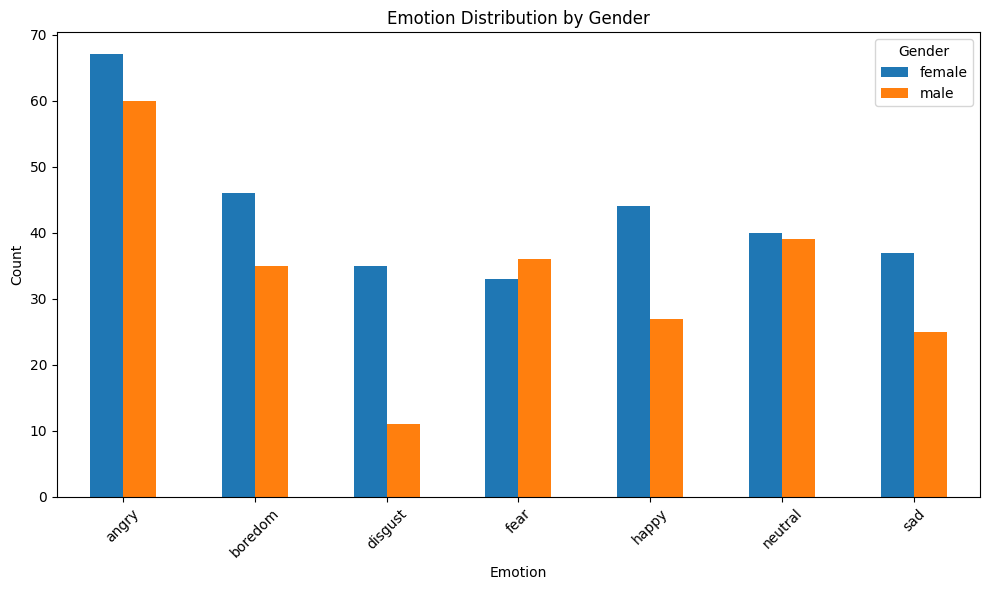

In [4]:
# visualization of emotions and speaker

speaker_gender = {
    '03': 'male',
    '08': 'female',
    '09': 'female',
    '10': 'male',
    '11': 'male',
    '12': 'male',
    '13': 'female',
    '14': 'female',
    '15': 'male',
    '16': 'female'
}
df["gender"] = df["speaker"].map(speaker_gender)

# print(df.head())

gender_emotion_counts = df.groupby(["emotion", "gender"]).size().unstack()

print(gender_emotion_counts)
import matplotlib.pyplot as plt

gender_emotion_counts.plot(kind='bar', figsize=(10, 6))

plt.title("Emotion Distribution by Gender")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()

plt.show()

gender
female    302
male      233
Name: count, dtype: int64


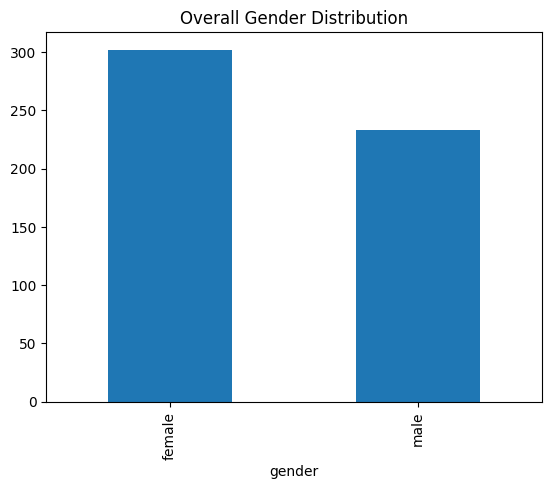

In [5]:
print(df["gender"].value_counts())
df["gender"].value_counts().plot(kind='bar')
plt.title("Overall Gender Distribution")
plt.show()

In [6]:
# augmentation functions .. added data augmentations to make 130 samples each

import numpy as np
import librosa

def add_noise(signal):
    noise = np.random.normal(0, 0.003, len(signal))  # reduced noise
    return signal + noise

def time_stretch(signal):
    rate = np.random.uniform(0.9, 1.1)  # random mild stretch
    return librosa.effects.time_stretch(signal, rate=rate)

def time_shift(signal):
    shift = np.random.randint(len(signal) * 0.1)
    return np.roll(signal, shift)

def change_gain(signal):
    gain = np.random.uniform(0.8, 1.2)
    return signal * gain

import os
import librosa
from collections import Counter

target_count = 130

X_audio = []
y_audio = []

for emotion in df["emotion"].unique():
    
    emotion_files = df[df["emotion"] == emotion]
    count = len(emotion_files)
    
    print(f"{emotion}: {count} original samples")
    
    # Add original samples
    for _, row in emotion_files.iterrows():
        file_path = os.path.join(emodb_path, row["file"])
        signal, sr = librosa.load(file_path, sr=16000)
        
        X_audio.append(signal)
        y_audio.append(emotion)
    
    # Number of augmented samples needed
    needed = target_count - count
    
    i = 0
    while needed > 0:
        row = emotion_files.iloc[i % len(emotion_files)]
        file_path = os.path.join(emodb_path, row["file"])
        
        signal, sr = librosa.load(file_path, sr=16000)
        
        # Random augmentation WITHOUT pitch change
        aug_type = np.random.choice(["noise", "stretch", "shift", "gain"])
        
        if aug_type == "noise":
            aug_signal = add_noise(signal)
        elif aug_type == "stretch":
            aug_signal = time_stretch(signal)
        elif aug_type == "shift":
            aug_signal = time_shift(signal)
        else:
            aug_signal = change_gain(signal)
        
        X_audio.append(aug_signal)
        y_audio.append(emotion)
        
        needed -= 1
        i += 1
print('after data augmentation:')
print("Total samples:", len(X_audio))
print("Class distribution:", Counter(y_audio))

happy: 71 original samples
neutral: 79 original samples
angry: 127 original samples
sad: 62 original samples
fear: 69 original samples
boredom: 81 original samples
disgust: 46 original samples
after data augmentation:
Total samples: 910
Class distribution: Counter({'happy': 130, 'neutral': 130, 'angry': 130, 'sad': 130, 'fear': 130, 'boredom': 130, 'disgust': 130})


In [7]:
# Extracting mfcc on entire speech signal

def extract_mfcc(signal, sr=16000, n_mfcc=26, max_len=200):
    
    # Normalize
    if np.max(np.abs(signal)) > 0:
        signal = signal / np.max(np.abs(signal))
    
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
    mfcc = mfcc.T
    
    # Padding / trimming
    if mfcc.shape[0] < max_len:
        mfcc = np.pad(mfcc, ((0, max_len - mfcc.shape[0]), (0, 0)))
    else:
        mfcc = mfcc[:max_len]
    
    return mfcc

X_mfcc = []

for signal in X_audio:
    mfcc = extract_mfcc(signal)
    X_mfcc.append(mfcc)

X_mfcc = np.array(X_mfcc)
y = np.array(y_audio)

print("Shape:", X_mfcc.shape)

Shape: (910, 200, 26)


In [8]:
from collections import Counter
print(Counter(y))
X_flat = X_mfcc.reshape(X_mfcc.shape[0], -1)

print("Flattened shape:", X_flat.shape)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

Counter({np.str_('happy'): 130, np.str_('neutral'): 130, np.str_('angry'): 130, np.str_('sad'): 130, np.str_('fear'): 130, np.str_('boredom'): 130, np.str_('disgust'): 130})
Flattened shape: (910, 5200)
['angry' 'boredom' 'disgust' 'fear' 'happy' 'neutral' 'sad']


In [9]:
import numpy as np

# indices of all samples
indices = np.arange(len(y))
angry_indices = indices[y == 'angry']
other_indices = indices[y != 'angry']
np.random.seed(42)  # reproducibility

selected_angry = np.random.choice(angry_indices, size=90, replace=False)
final_indices = np.concatenate([selected_angry, other_indices])
X_mfcc_balanced = X_mfcc[final_indices]
y_balanced = y[final_indices]
from sklearn.utils import shuffle

X_mfcc_balanced, y_balanced = shuffle(X_mfcc_balanced, y_balanced, random_state=42)
from collections import Counter

print(Counter(y_balanced))
print("New shape:", X_mfcc_balanced.shape)

Counter({np.str_('sad'): 130, np.str_('fear'): 130, np.str_('disgust'): 130, np.str_('neutral'): 130, np.str_('happy'): 130, np.str_('boredom'): 130, np.str_('angry'): 90})
New shape: (870, 200, 26)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
svm.fit(X_train, y_train)
from sklearn.metrics import classification_report

y_pred = svm.predict(X_test)

print("Accuracy:", svm.score(X_test, y_test))
print(classification_report(y_test, y_pred))

Accuracy: 0.8076923076923077
              precision    recall  f1-score   support

           0       0.76      0.72      0.74        36
           1       0.81      0.68      0.74        25
           2       0.95      0.83      0.89        24
           3       0.79      0.96      0.86        23
           4       0.76      0.70      0.73        27
           5       0.74      0.83      0.78        24
           6       0.88      1.00      0.94        23

    accuracy                           0.81       182
   macro avg       0.81      0.82      0.81       182
weighted avg       0.81      0.81      0.81       182



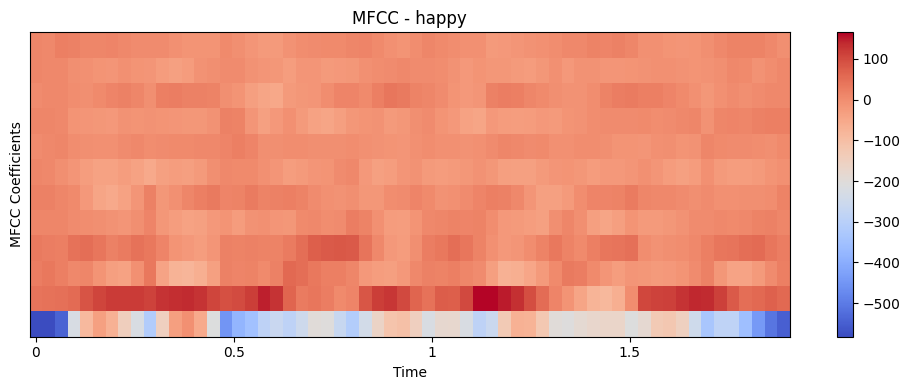

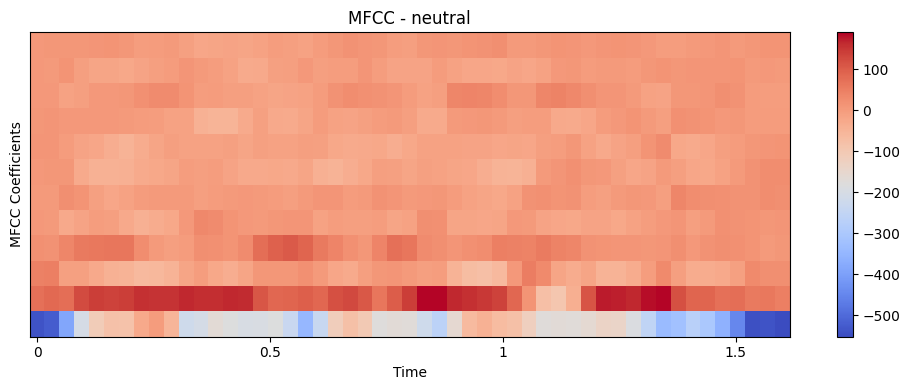

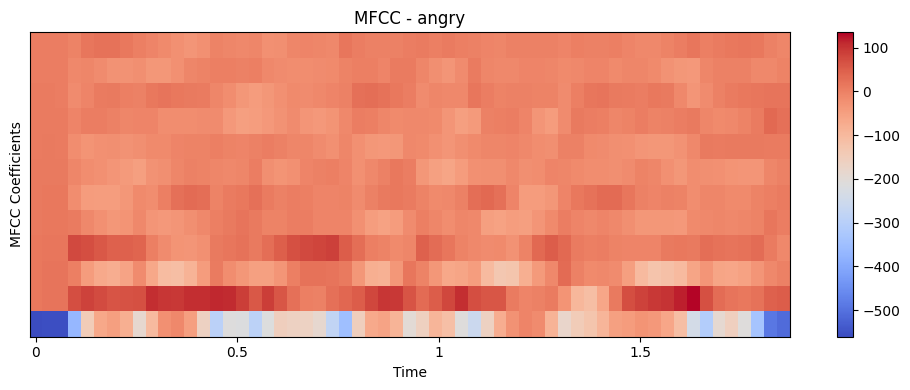

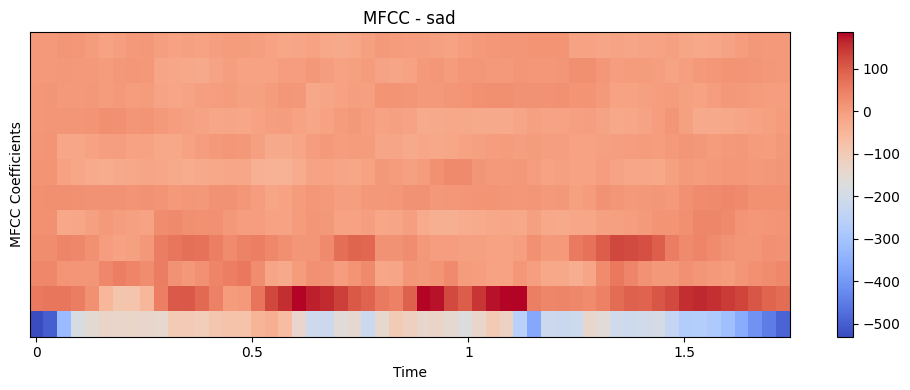

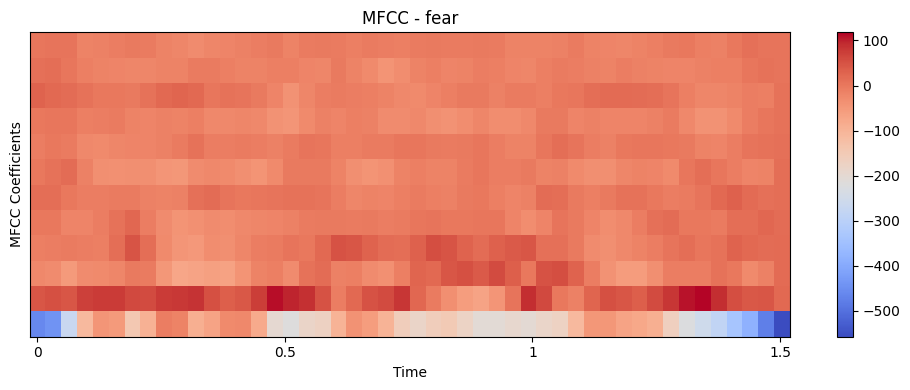

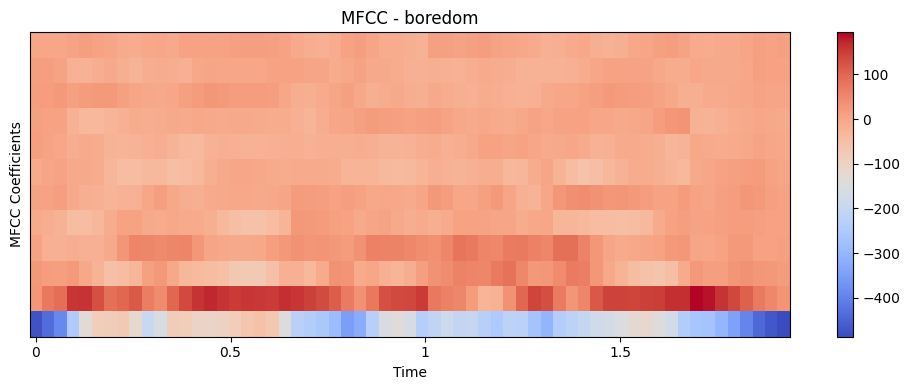

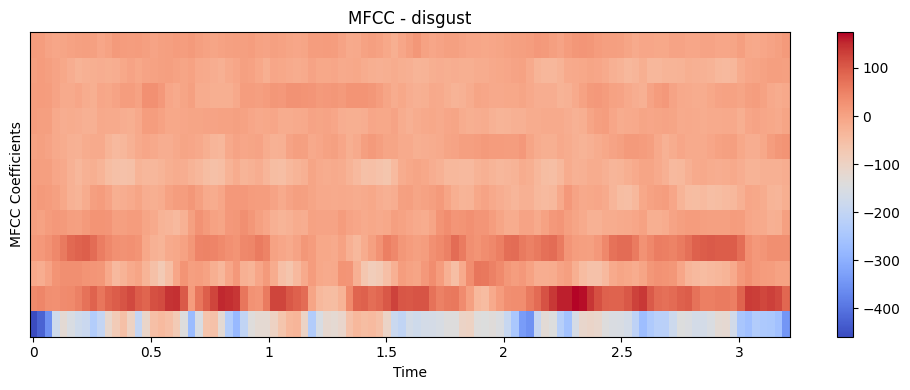

In [11]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Pick one sample per emotion
sample_files = {}

for emotion in df["emotion"].unique():
    file_row = df[df["emotion"] == emotion].iloc[0]
    sample_files[emotion] = os.path.join(emodb_path, file_row["file"])


# Plot MFCCs
for emotion, file_path in sample_files.items():
    
    signal, sr = librosa.load(file_path, sr=16000)
    
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=12)
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc, x_axis='time', sr=sr)
    plt.colorbar()
    
    plt.title(f"MFCC - {emotion}")
    plt.xlabel("Time")
    plt.ylabel("MFCC Coefficients")
    
    plt.tight_layout()
    plt.show()

## Vowel Regions:

Extracting vowel-region features...


c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1664
  warnings.warn(
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1536
  warnings.warn(
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1152
  warnings.warn(
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1280
  warnings.warn(
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1792
  warnings.warn(
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft

Vowel feature shape: (910, 270)
Fused feature shape: (910, 5470)

Full-signal MFCCs (baseline)  —  Accuracy: 0.8077
              precision    recall  f1-score   support

       angry       0.76      0.72      0.74        36
     boredom       0.81      0.68      0.74        25
     disgust       0.95      0.83      0.89        24
        fear       0.79      0.96      0.86        23
       happy       0.76      0.70      0.73        27
     neutral       0.74      0.83      0.78        24
         sad       0.88      1.00      0.94        23

    accuracy                           0.81       182
   macro avg       0.81      0.82      0.81       182
weighted avg       0.81      0.81      0.81       182


Vowel-region features only  —  Accuracy: 0.7912
              precision    recall  f1-score   support

       angry       0.77      0.67      0.72        36
     boredom       0.90      0.76      0.83        25
     disgust       0.87      0.83      0.85        24
        fear       0.

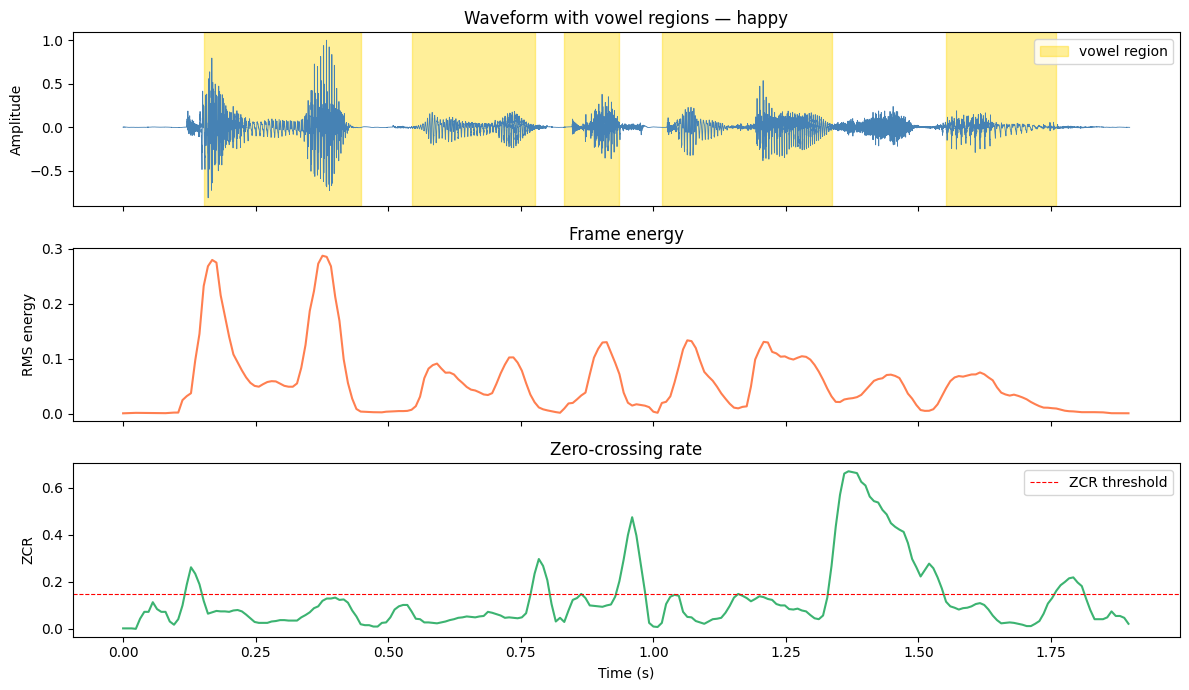

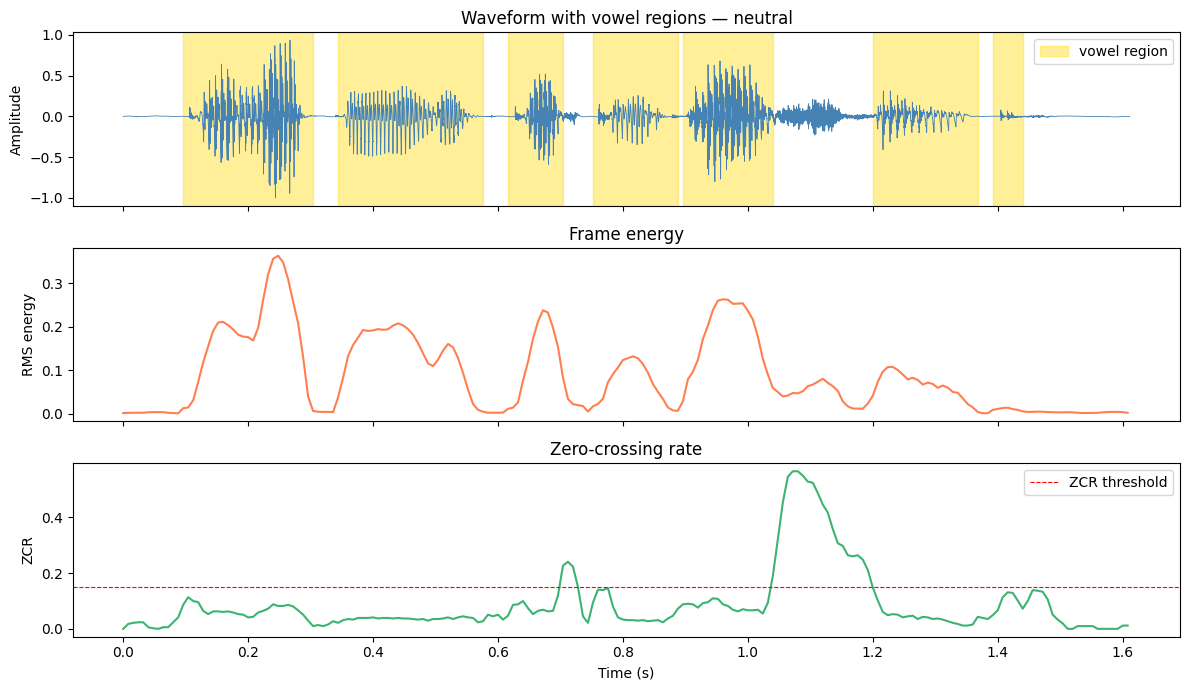

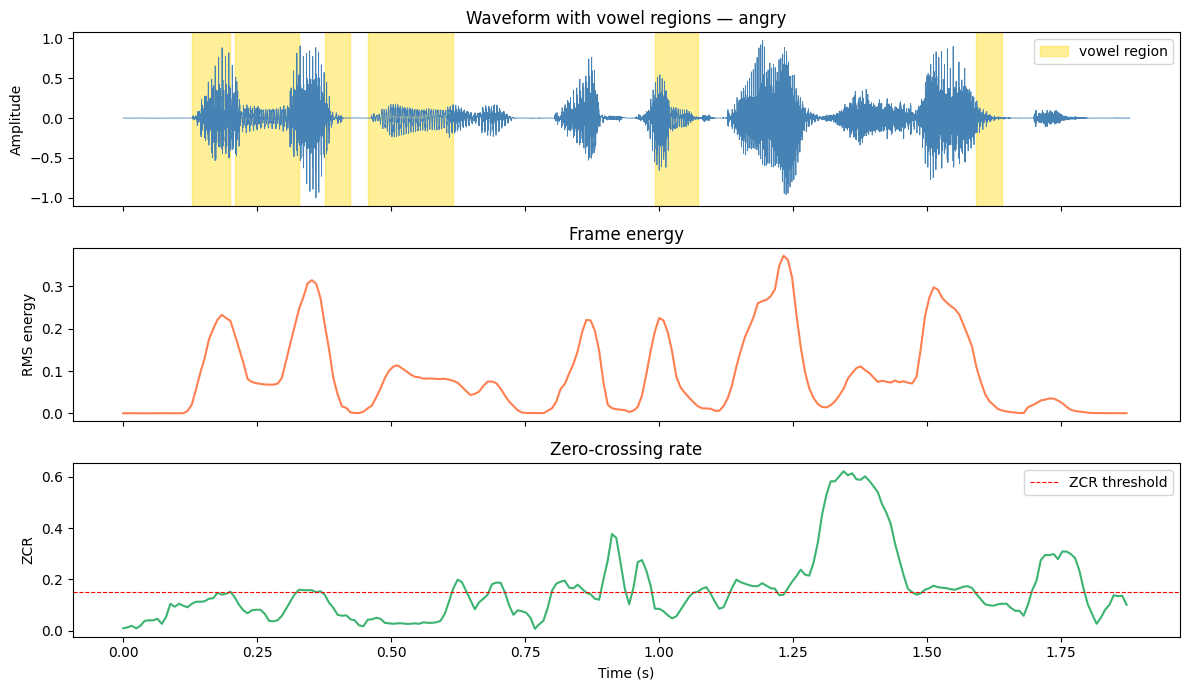

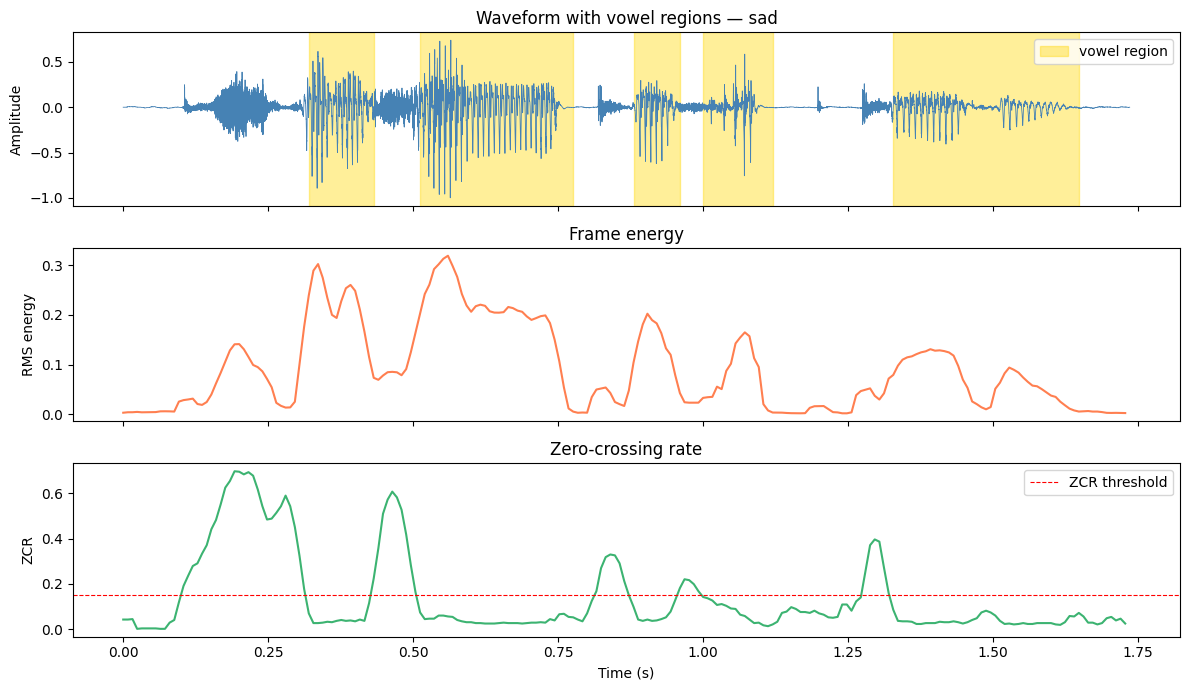

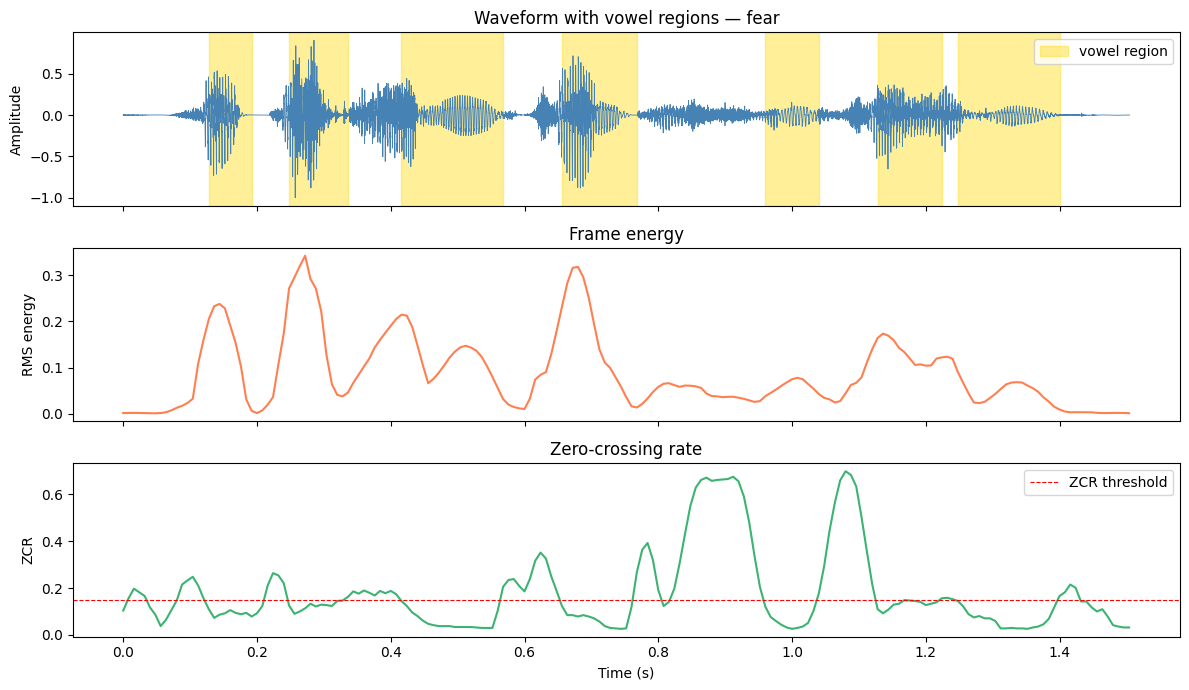

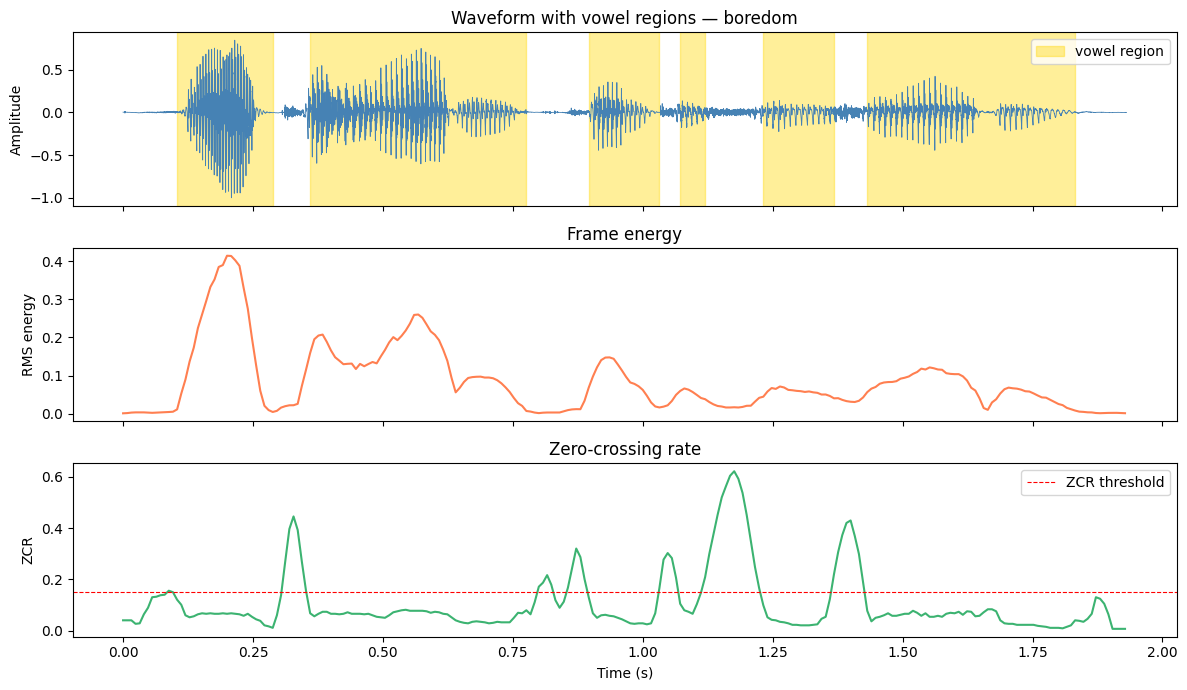

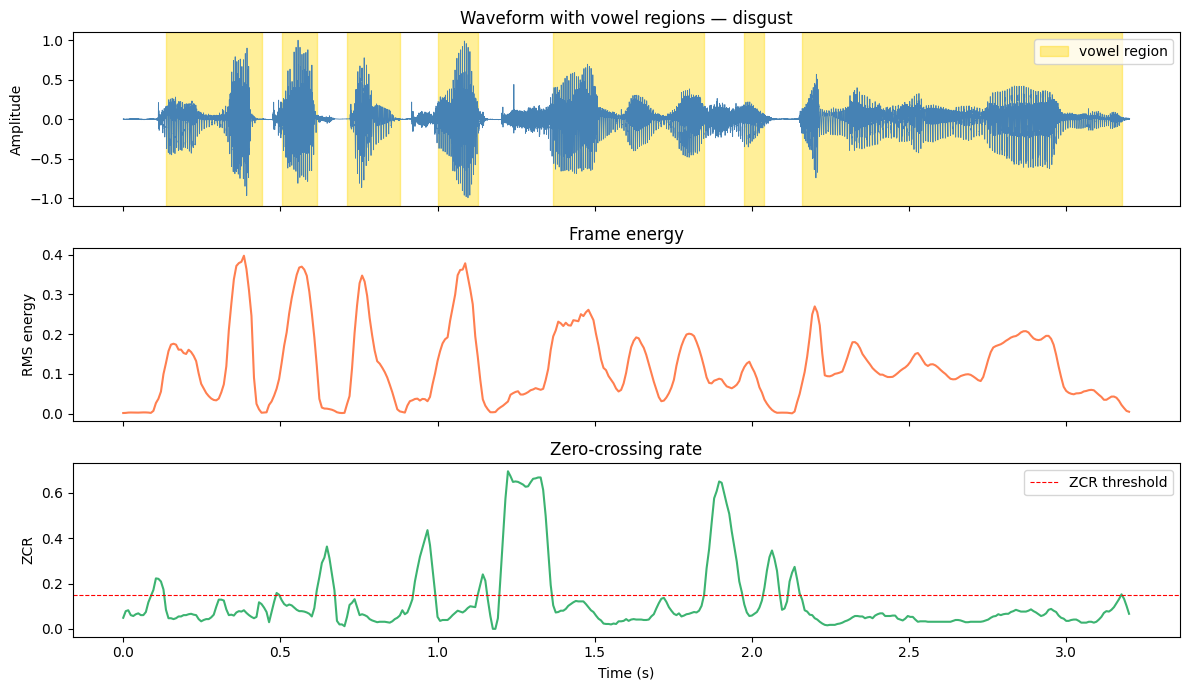


Emotion       Avg vowel count  Avg vowel dur (s)
------------------------------------------------
happy                    8.24              1.377
neutral                  6.81              1.668
angry                    8.34              1.121
sad                     11.40              2.910
fear                     7.45              1.285
boredom                  7.05              2.000
disgust                  8.85              1.922


In [12]:
# ============================================================
# VOWEL REGION DETECTION & FEATURE EXTRACTION
# ============================================================

import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from collections import Counter


# ── 1. Vowel region detector ────────────────────────────────
def detect_vowel_regions(signal, sr=16000,
                          frame_len=512, hop_len=128,
                          energy_threshold=0.02,
                          zcr_threshold=0.15,
                          min_vowel_dur=0.05):
    """
    Detect vowel-like regions using energy + ZCR.
    
    Vowels: HIGH energy, LOW zero-crossing rate
    Consonants/silence: low energy OR high ZCR
    
    Returns list of (start_sample, end_sample) tuples.
    """
    # Frame-level energy (RMS)
    rms = librosa.feature.rms(y=signal, frame_length=frame_len,
                               hop_length=hop_len)[0]
    
    # Frame-level zero-crossing rate
    zcr = librosa.feature.zero_crossing_rate(signal, frame_length=frame_len,
                                              hop_length=hop_len)[0]
    
    # Normalize energy to [0, 1] for threshold robustness
    rms_norm = rms / (np.max(rms) + 1e-8)
    
    # Vowel mask: high energy AND low ZCR
    vowel_mask = (rms_norm > energy_threshold) & (zcr < zcr_threshold)
    
    # Convert frame mask to sample-level segments
    min_frames = int(min_vowel_dur * sr / hop_len)
    regions = []
    in_vowel = False
    start_frame = 0

    for i, is_vowel in enumerate(vowel_mask):
        if is_vowel and not in_vowel:
            start_frame = i
            in_vowel = True
        elif not is_vowel and in_vowel:
            if (i - start_frame) >= min_frames:
                start_samp = start_frame * hop_len
                end_samp = min(i * hop_len, len(signal))
                regions.append((start_samp, end_samp))
            in_vowel = False

    if in_vowel and (len(vowel_mask) - start_frame) >= min_frames:
        regions.append((start_frame * hop_len,
                        min(len(vowel_mask) * hop_len, len(signal))))

    return regions


# ── 2. Feature extraction from vowel regions ────────────────
def extract_formant_approx(segment, sr=16000, n_lpc=10):
    """
    Approximate F1/F2 via LPC pole frequencies.
    LPC is computationally light and well-suited for short vowel segments.
    """
    if len(segment) < n_lpc + 1:
        return 0.0, 0.0

    # Pre-emphasis
    pre = np.append(segment[0], segment[1:] - 0.97 * segment[:-1])

    try:
        # LPC coefficients
        lpc_coeffs = librosa.lpc(pre, order=n_lpc)
        
        # Roots of LPC polynomial → pole frequencies
        roots = np.roots(lpc_coeffs)
        roots = roots[np.imag(roots) >= 0]  # keep upper half-plane
        
        angles = np.angle(roots)
        freqs = angles * (sr / (2 * np.pi))
        freqs = np.sort(freqs[freqs > 50])  # ignore DC
        
        f1 = freqs[0] if len(freqs) > 0 else 0.0
        f2 = freqs[1] if len(freqs) > 1 else 0.0
        return f1, f2
    except Exception:
        return 0.0, 0.0


def extract_vowel_features(signal, sr=16000, n_mfcc=26, max_regions=5):
    """
    For each detected vowel region:
      - Extract MFCCs (mean across frames in region)
      - Approximate F1, F2 formants via LPC
    
    Aggregate across regions → fixed-size feature vector.
    """
    regions = detect_vowel_regions(signal, sr)
    
    region_features = []
    for (start, end) in regions[:max_regions]:
        seg = signal[start:end]
        if len(seg) < 512:
            continue
        
        # MFCC means over the segment
        mfcc = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc, axis=1)          # (n_mfcc,)
        mfcc_std  = np.std(mfcc, axis=1)           # (n_mfcc,)
        
        # Formants
        f1, f2 = extract_formant_approx(seg, sr)
        
        # Concat: [mfcc_mean | mfcc_std | f1 | f2]
        feat = np.concatenate([mfcc_mean, mfcc_std, [f1, f2]])
        region_features.append(feat)
    
    feat_dim = 2 * n_mfcc + 2  # per-region feature size
    
    if len(region_features) == 0:
        # Silence / no vowels detected → zeros
        return np.zeros(max_regions * feat_dim)
    
    # Pad or trim to max_regions
    while len(region_features) < max_regions:
        region_features.append(np.zeros(feat_dim))
    region_features = region_features[:max_regions]
    
    return np.concatenate(region_features)   # (max_regions * feat_dim,)


# ── 3. Build vowel feature matrix from X_audio ──────────────
print("Extracting vowel-region features...")

X_vowel = []
for signal in X_audio:
    feat = extract_vowel_features(signal)
    X_vowel.append(feat)

X_vowel = np.array(X_vowel)
print(f"Vowel feature shape: {X_vowel.shape}")
# → (n_samples, max_regions * (2*n_mfcc + 2))


# ── 4. Fused feature matrix ──────────────────────────────────
# X_flat is your existing full-signal flattened MFCC array
X_fused = np.concatenate([X_flat, X_vowel], axis=1)
print(f"Fused feature shape: {X_fused.shape}")


# ── 5. Train & compare three SVMs ───────────────────────────
def run_svm(X, y_enc, label="Model"):
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sc, y_enc, test_size=0.2, random_state=42
    )
    svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
    svm.fit(X_tr, y_tr)
    
    acc = svm.score(X_te, y_te)
    print(f"\n{'='*50}")
    print(f"{label}  —  Accuracy: {acc:.4f}")
    print(classification_report(y_te, svm.predict(X_te),
                                 target_names=le.classes_))
    return acc

acc_full   = run_svm(X_flat,   y_encoded, "Full-signal MFCCs (baseline)")
acc_vowel  = run_svm(X_vowel,  y_encoded, "Vowel-region features only")
acc_fused  = run_svm(X_fused,  y_encoded, "Fused (full + vowel)")

print(f"\n{'='*50}")
print(f"Baseline  : {acc_full:.4f}")
print(f"Vowel only: {acc_vowel:.4f}")
print(f"Fused     : {acc_fused:.4f}")
print(f"Delta (fused vs baseline): {acc_fused - acc_full:+.4f}")


# ── 6. Visualise vowel regions on a sample waveform ─────────
def plot_vowel_regions(file_path, emotion, sr=16000):
    signal, _ = librosa.load(file_path, sr=sr)
    regions    = detect_vowel_regions(signal, sr)
    times      = np.linspace(0, len(signal)/sr, len(signal))

    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

    # Waveform + highlighted vowel spans
    axes[0].plot(times, signal, color='steelblue', lw=0.6)
    for (s, e) in regions:
        axes[0].axvspan(s/sr, e/sr, color='gold', alpha=0.4, label='vowel region')
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title(f"Waveform with vowel regions — {emotion}")
    handles, labels_ = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend([handles[0]], ["vowel region"], loc='upper right')

    # RMS energy
    rms = librosa.feature.rms(y=signal, frame_length=512, hop_length=128)[0]
    t_frames = librosa.frames_to_time(np.arange(len(rms)),
                                       sr=sr, hop_length=128)
    axes[1].plot(t_frames, rms, color='coral')
    axes[1].set_ylabel("RMS energy")
    axes[1].set_title("Frame energy")

    # ZCR
    zcr = librosa.feature.zero_crossing_rate(signal, frame_length=512,
                                              hop_length=128)[0]
    axes[2].plot(t_frames, zcr, color='mediumseagreen')
    axes[2].axhline(0.15, color='red', ls='--', lw=0.8, label='ZCR threshold')
    axes[2].set_ylabel("ZCR")
    axes[2].set_title("Zero-crossing rate")
    axes[2].set_xlabel("Time (s)")
    axes[2].legend(loc='upper right')

    plt.tight_layout()
    plt.show()


# Plot one sample per emotion
for emotion, file_path in sample_files.items():
    plot_vowel_regions(file_path, emotion)


# ── 7. Vowel count & duration stats per emotion ─────────────
vowel_stats = {e: {'count': [], 'duration': []} for e in df["emotion"].unique()}

for _, row in df.iterrows():
    fp = os.path.join(emodb_path, row["file"])
    signal, sr = librosa.load(fp, sr=16000)
    regions = detect_vowel_regions(signal, sr)
    
    vowel_stats[row["emotion"]]['count'].append(len(regions))
    total_dur = sum((e - s) for s, e in regions) / sr
    vowel_stats[row["emotion"]]['duration'].append(total_dur)

# Summary table
print(f"\n{'Emotion':<12} {'Avg vowel count':>16} {'Avg vowel dur (s)':>18}")
print("-" * 48)
for emotion, stats in vowel_stats.items():
    avg_cnt = np.mean(stats['count'])
    avg_dur = np.mean(stats['duration'])
    print(f"{emotion:<12} {avg_cnt:>16.2f} {avg_dur:>18.3f}")

### VOP and VEP:

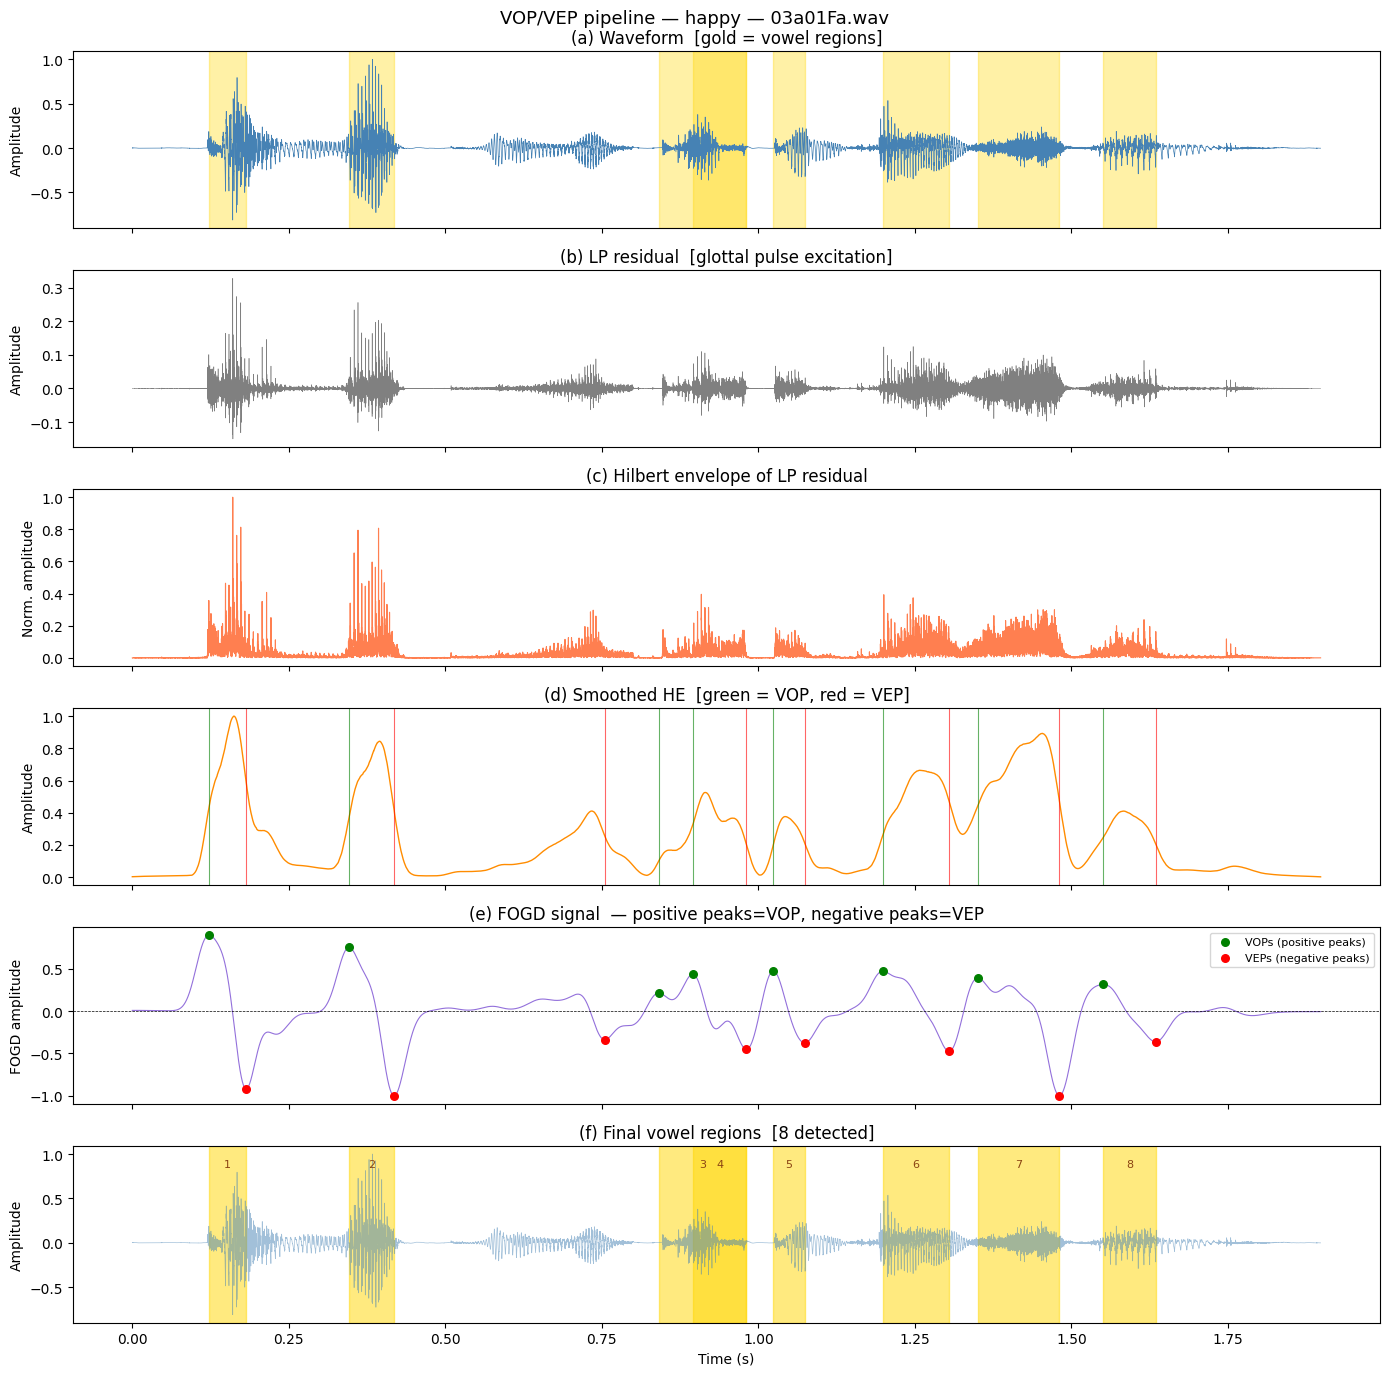


happy — 03a01Fa.wav
  VOPs detected : 8
  VEPs detected : 8
  Paired regions: 8
    [1] 0.123s – 0.182s  (59 ms)
    [2] 0.346s – 0.418s  (72 ms)
    [3] 0.841s – 0.981s  (140 ms)
    [4] 0.895s – 0.981s  (86 ms)
    [5] 1.024s – 1.074s  (50 ms)
    [6] 1.199s – 1.305s  (106 ms)
    [7] 1.351s – 1.481s  (130 ms)
    [8] 1.551s – 1.635s  (84 ms)


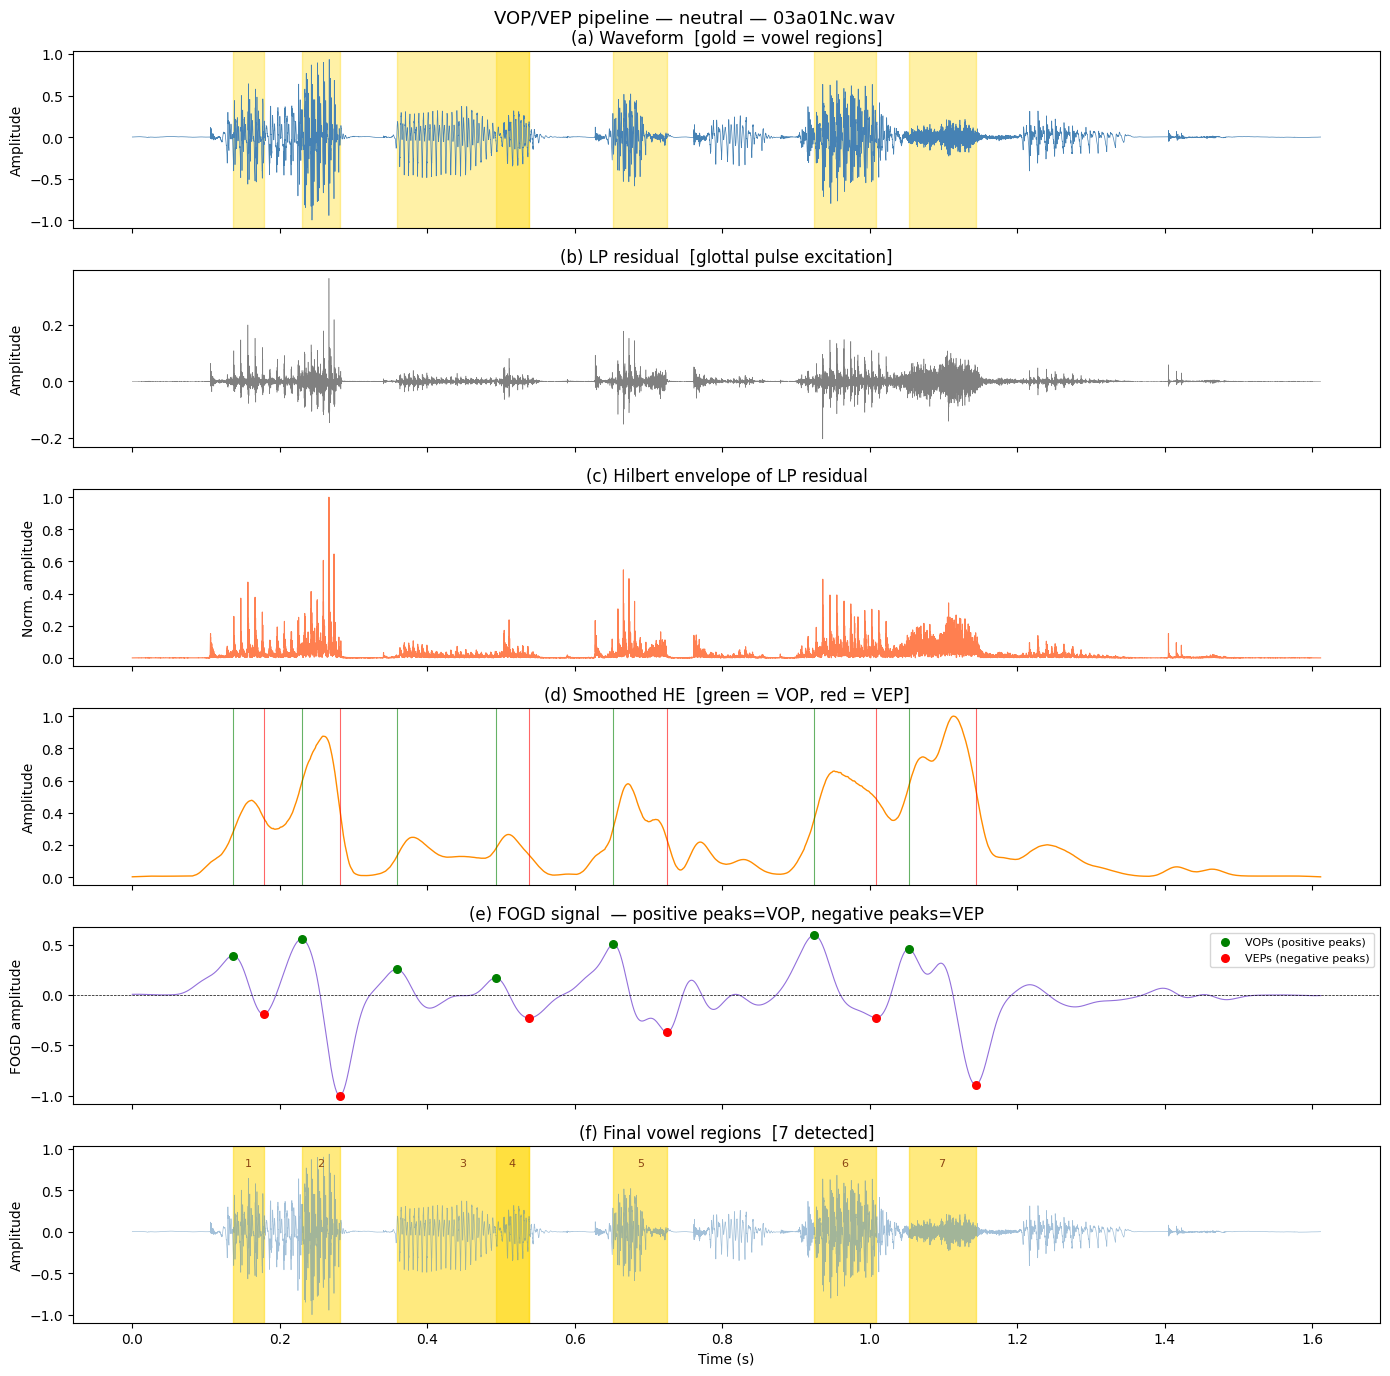


neutral — 03a01Nc.wav
  VOPs detected : 7
  VEPs detected : 6
  Paired regions: 7
    [1] 0.137s – 0.178s  (41 ms)
    [2] 0.230s – 0.281s  (52 ms)
    [3] 0.358s – 0.538s  (180 ms)
    [4] 0.493s – 0.538s  (46 ms)
    [5] 0.652s – 0.725s  (72 ms)
    [6] 0.924s – 1.008s  (84 ms)
    [7] 1.053s – 1.143s  (91 ms)


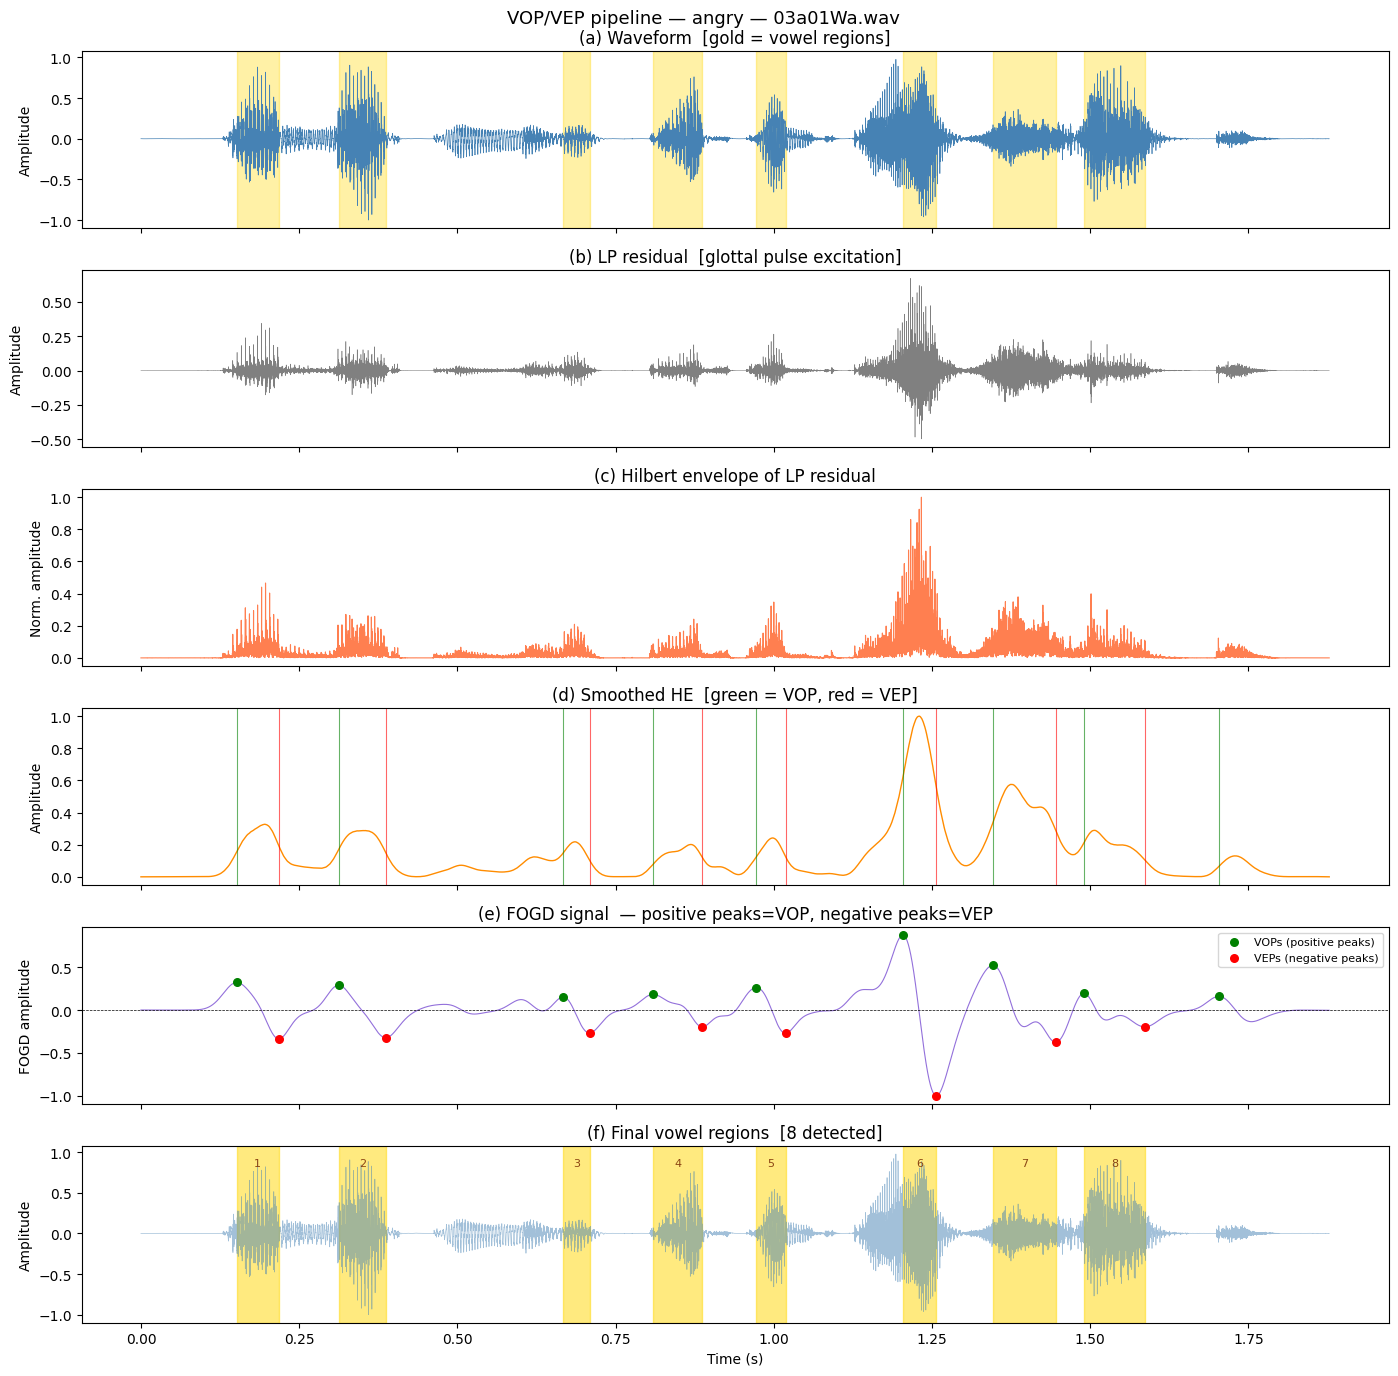


angry — 03a01Wa.wav
  VOPs detected : 9
  VEPs detected : 8
  Paired regions: 8
    [1] 0.151s – 0.218s  (66 ms)
    [2] 0.312s – 0.387s  (74 ms)
    [3] 0.667s – 0.709s  (42 ms)
    [4] 0.809s – 0.887s  (78 ms)
    [5] 0.972s – 1.019s  (46 ms)
    [6] 1.204s – 1.257s  (53 ms)
    [7] 1.346s – 1.446s  (99 ms)
    [8] 1.490s – 1.586s  (96 ms)


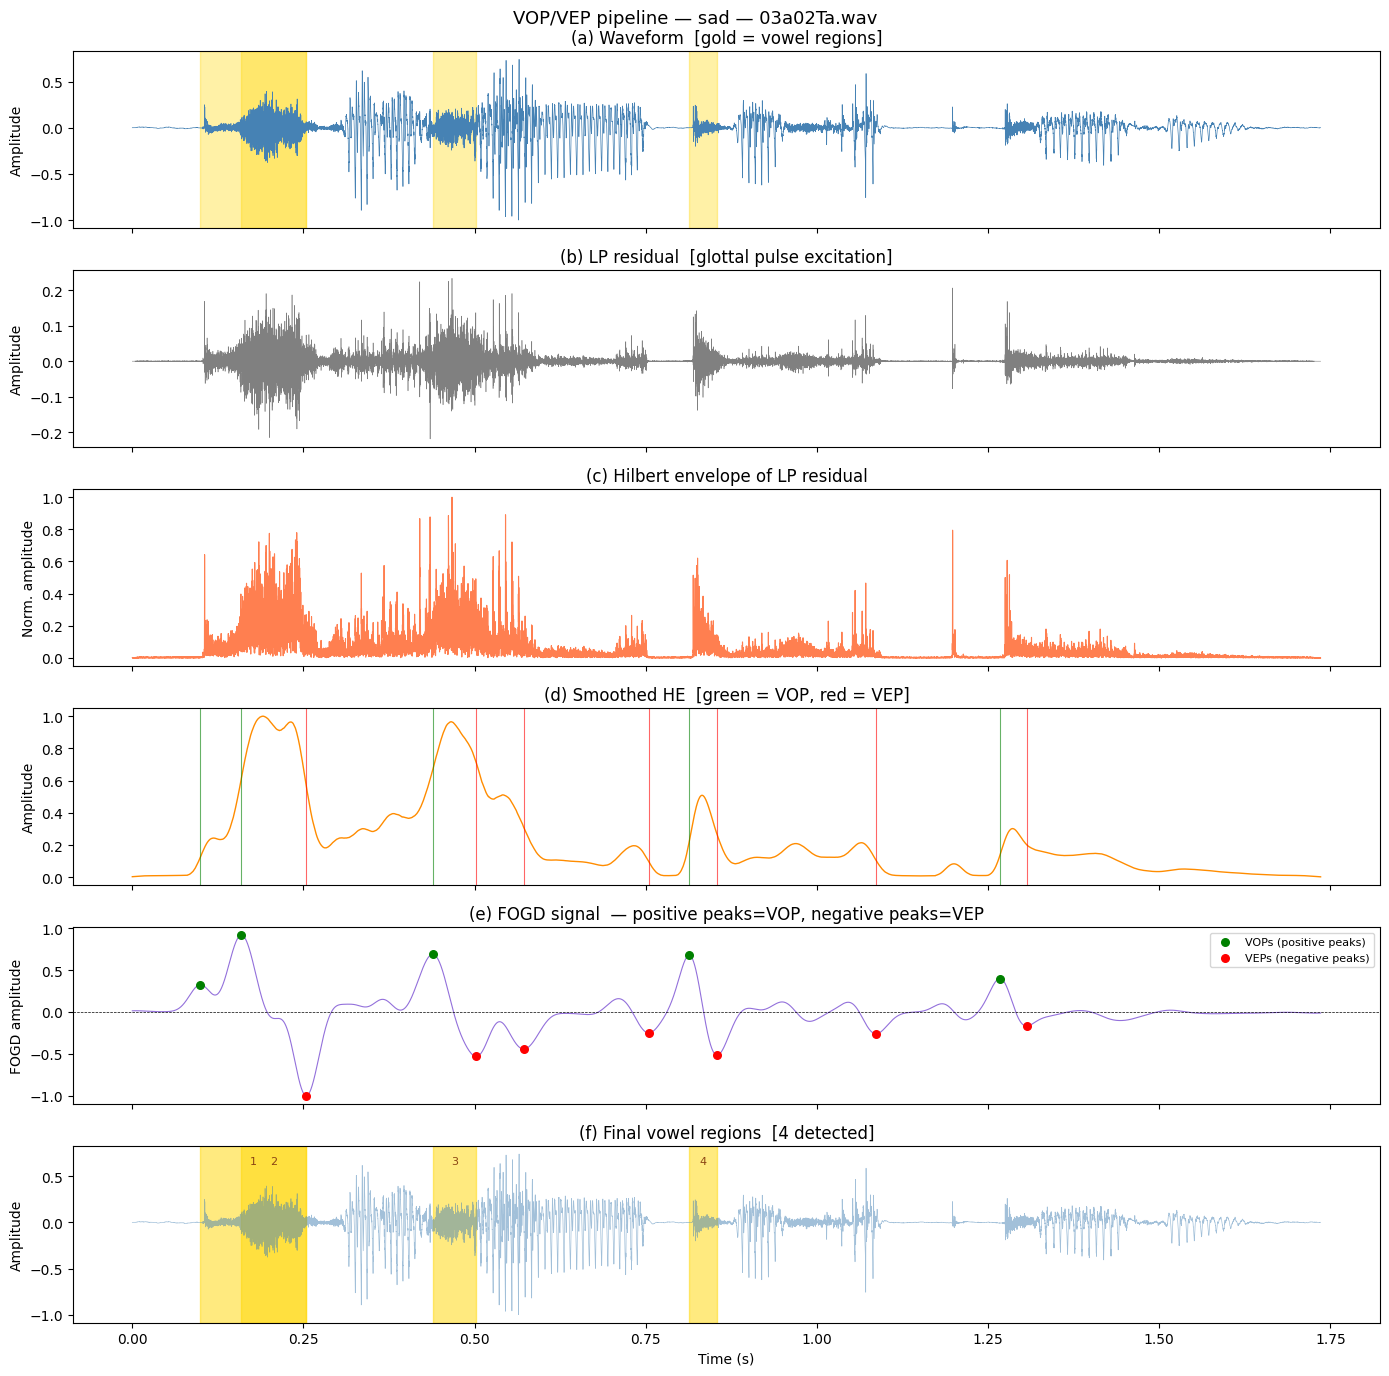


sad — 03a02Ta.wav
  VOPs detected : 5
  VEPs detected : 7
  Paired regions: 4
    [1] 0.100s – 0.254s  (155 ms)
    [2] 0.159s – 0.254s  (95 ms)
    [3] 0.439s – 0.502s  (64 ms)
    [4] 0.813s – 0.854s  (41 ms)


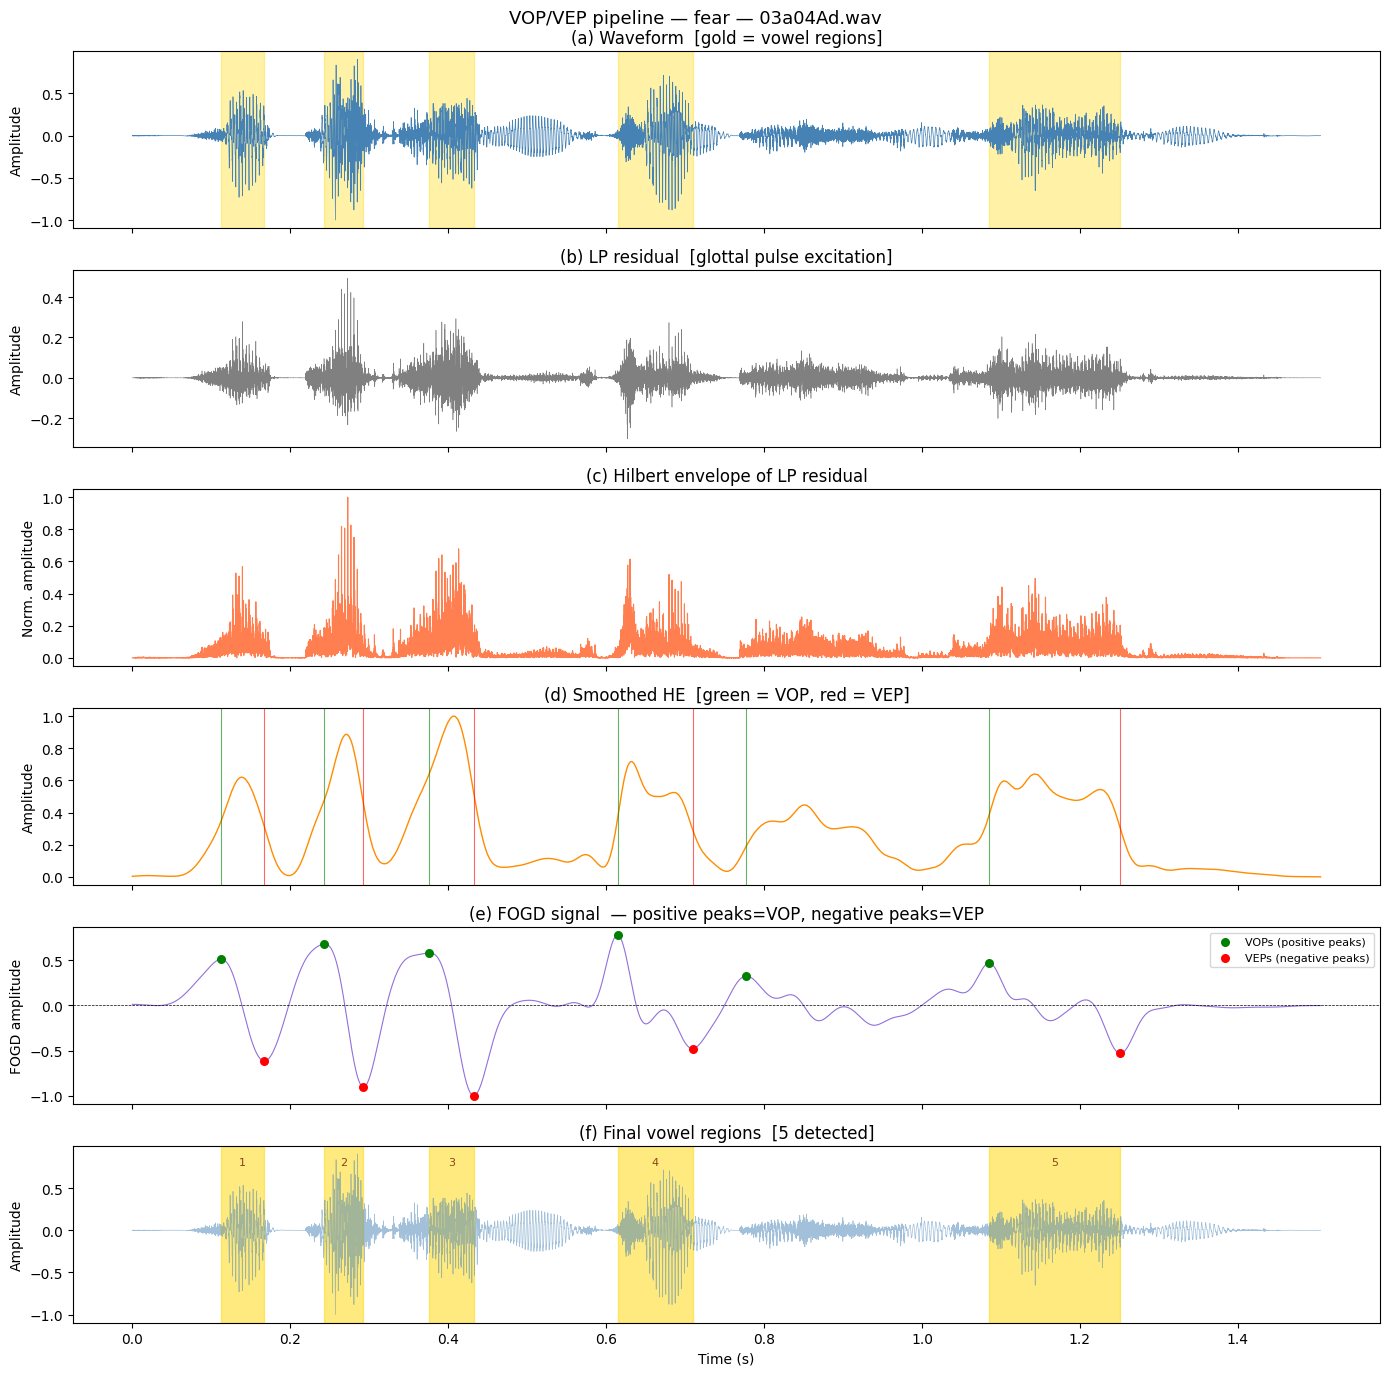


fear — 03a04Ad.wav
  VOPs detected : 6
  VEPs detected : 5
  Paired regions: 5
    [1] 0.112s – 0.167s  (55 ms)
    [2] 0.243s – 0.293s  (49 ms)
    [3] 0.376s – 0.432s  (56 ms)
    [4] 0.614s – 0.709s  (95 ms)
    [5] 1.085s – 1.251s  (166 ms)


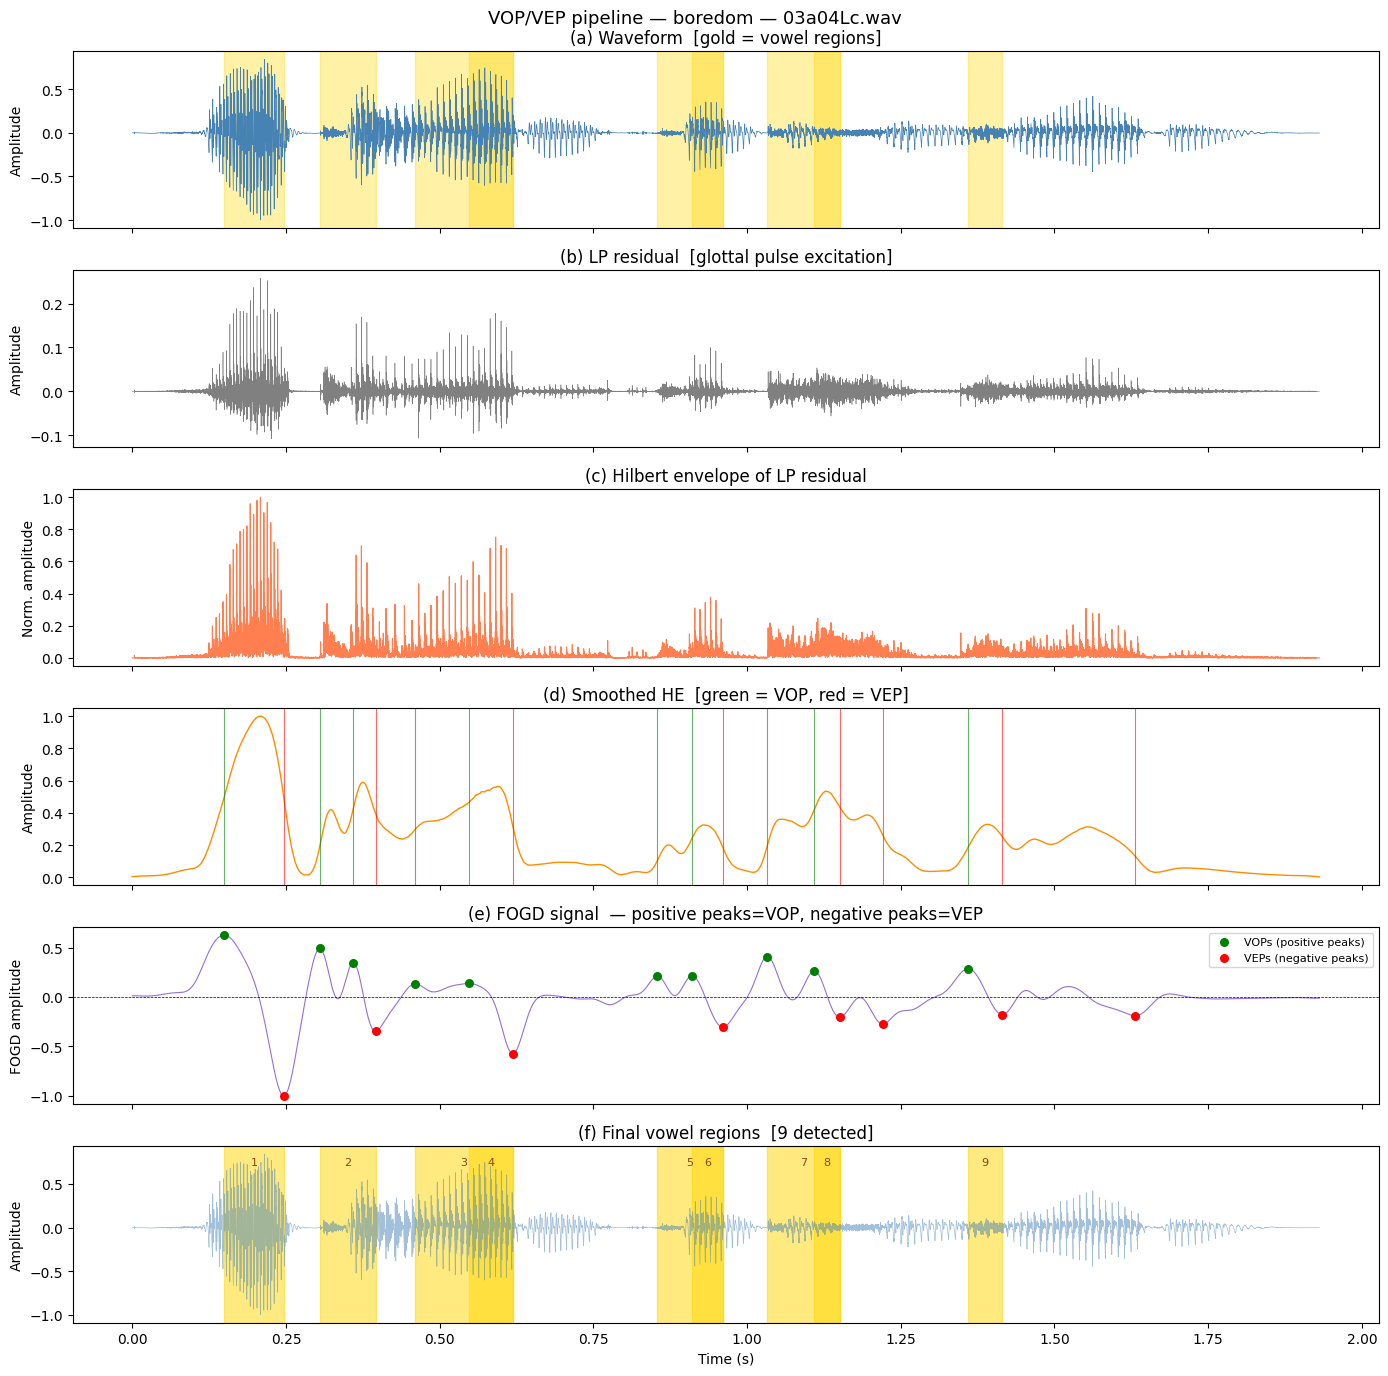


boredom — 03a04Lc.wav
  VOPs detected : 10
  VEPs detected : 8
  Paired regions: 9
    [1] 0.150s – 0.246s  (97 ms)
    [2] 0.305s – 0.396s  (91 ms)
    [3] 0.461s – 0.619s  (158 ms)
    [4] 0.548s – 0.619s  (71 ms)
    [5] 0.854s – 0.961s  (106 ms)
    [6] 0.911s – 0.961s  (50 ms)
    [7] 1.033s – 1.151s  (118 ms)
    [8] 1.109s – 1.151s  (42 ms)
    [9] 1.360s – 1.415s  (56 ms)


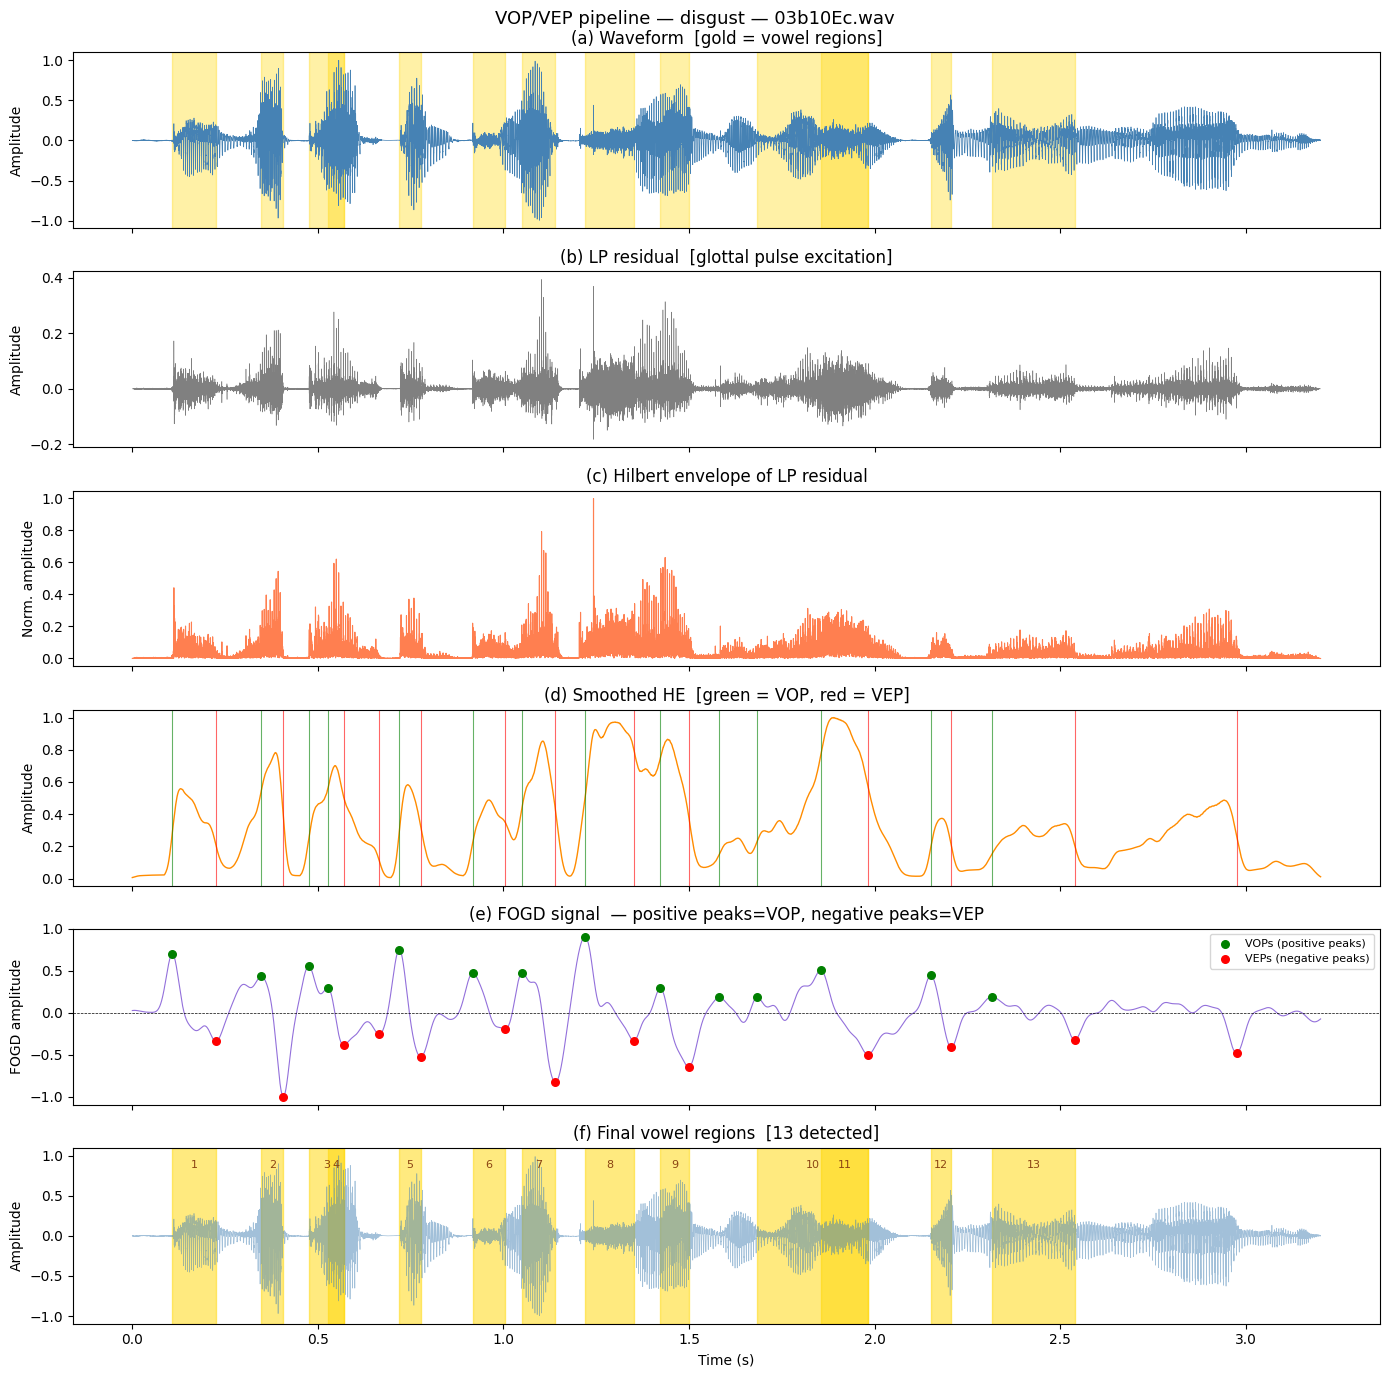


disgust — 03b10Ec.wav
  VOPs detected : 14
  VEPs detected : 13
  Paired regions: 13
    [1] 0.108s – 0.225s  (118 ms)
    [2] 0.347s – 0.407s  (60 ms)
    [3] 0.475s – 0.570s  (94 ms)
    [4] 0.526s – 0.570s  (44 ms)
    [5] 0.719s – 0.777s  (58 ms)
    [6] 0.918s – 1.004s  (87 ms)
    [7] 1.051s – 1.140s  (89 ms)
    [8] 1.220s – 1.351s  (132 ms)
    [9] 1.423s – 1.499s  (76 ms)
    [10] 1.684s – 1.982s  (298 ms)
    [11] 1.855s – 1.982s  (128 ms)
    [12] 2.151s – 2.207s  (55 ms)
    [13] 2.316s – 2.539s  (223 ms)

Extracting VOP/VEP vowel features for all augmented samples...


c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=946
  warnings.warn(
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1152
  warnings.warn(
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1374
  warnings.warn(
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=803
  warnings.warn(
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=701
  warnings.warn(
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=20

VOP/VEP vowel feature shape: (910, 270)

VOP/VEP vowel features only  —  Accuracy: 0.7637
              precision    recall  f1-score   support

       angry       0.65      0.67      0.66        36
     boredom       0.73      0.76      0.75        25
     disgust       1.00      0.92      0.96        24
        fear       0.83      0.83      0.83        23
       happy       0.67      0.67      0.67        27
     neutral       0.65      0.71      0.68        24
         sad       0.95      0.87      0.91        23

    accuracy                           0.76       182
   macro avg       0.78      0.77      0.78       182
weighted avg       0.77      0.76      0.77       182


Fused (full MFCC + VOP/VEP)  —  Accuracy: 0.8242
              precision    recall  f1-score   support

       angry       0.75      0.75      0.75        36
     boredom       0.89      0.68      0.77        25
     disgust       0.95      0.88      0.91        24
        fear       0.87      0.87      0.87   

In [13]:
# ============================================================
# VOP / VEP DETECTION  — EmoDB pipeline extension
# Replaces the earlier RMS+ZCR+flatness detector entirely.
# Method: LPC residual → Hilbert envelope → smooth → FOGD
#         positive peaks = VOPs (onsets), negative peaks = VEPs (offsets)
# ============================================================

import numpy as np
import librosa
from scipy.signal import lfilter, hilbert, find_peaks
from scipy.signal.windows import hamming, gaussian


# ── 1. LP Residual ───────────────────────────────────────────
def compute_lp_residual(signal, sr, lpc_order=10,
                         frame_ms=20, hop_ms=10):
    """
    Frame the signal, apply LPC per frame, collect inverse-filter output.
    
    LPC models the vocal tract as an all-pole filter A(z).
    Filtering the speech through A(z) removes the vocal tract,
    leaving behind the excitation (glottal pulses + noise) = LP residual.
    
    This is the key step: the residual has sharp peaks at glottal closure
    instants (GCIs), which is exactly what drives VOP/VEP detection.
    """
    frame_len = int(frame_ms / 1000 * sr)
    hop_len   = int(hop_ms  / 1000 * sr)
    
    # Pre-emphasis — boosts high frequencies, improves LPC conditioning
    pre = np.append(signal[0], signal[1:] - 0.97 * signal[:-1])
    
    residual = np.zeros_like(pre)
    win      = hamming(frame_len)
    
    for start in range(0, len(pre) - frame_len, hop_len):
        frame    = pre[start : start + frame_len] * win
        lpc_coef = librosa.lpc(frame, order=lpc_order)   # returns [1, a1, a2, ...]
        
        # lfilter(b, a, x): b=LPC coeffs (analysis filter), a=[1]
        frame_residual = lfilter(lpc_coef, [1.0], frame)
        
        # Overlap-add accumulation
        residual[start : start + frame_len] += frame_residual
    
    return residual


# ── 2. Hilbert Envelope ──────────────────────────────────────
def hilbert_envelope(residual):
    """
    |H{residual}| gives the instantaneous amplitude (envelope).
    
    The Hilbert transform produces an analytic signal whose magnitude
    traces the 'outline' of the waveform — peaks at each glottal pulse,
    valleys between pulses. This is what we smooth and differentiate.
    """
    he = np.abs(hilbert(residual))
    he /= (np.max(he) + 1e-8)   # normalize to [0,1]
    return he


# ── 3. Smoothing ─────────────────────────────────────────────
def smooth_envelope(he, sr, window_ms=50):
    """
    Convolve the Hilbert envelope with a normalized Hamming window.
    
    50ms is long enough to bridge individual glottal pulses (which occur
    at ~8-14ms intervals for typical F0), but short enough to track the
    syllable-level energy contour that drives VOP/VEP detection.
    """
    win_len = int(window_ms / 1000 * sr)
    if win_len % 2 == 0:
        win_len += 1
    win = hamming(win_len)
    win /= win.sum()
    
    smoothed = np.convolve(he, win, mode='same')
    
    # Restore amplitude scale after convolution
    smoothed *= (np.max(he) / (np.max(smoothed) + 1e-8))
    return smoothed


# ── 4. FOGD (First-Order Gaussian Derivative) ────────────────
def compute_fogd(smoothed, sr, kernel_ms=80, std_fraction=6):
    """
    Convolve the smoothed envelope with the derivative of a Gaussian.
    
    Why Gaussian derivative and not plain np.diff?
    ─────────────────────────────────────────────
    np.diff is noisy — it amplifies high-frequency jitter in the envelope.
    The Gaussian derivative is a smoothed differentiator:
      • The Gaussian part suppresses noise
      • The derivative part detects slope changes
    
    The result: a signal whose
      • positive peaks  = rising slopes in smoothed_he  = VOWEL ONSETS  (VOPs)
      • negative peaks  = falling slopes in smoothed_he = VOWEL OFFSETS (VEPs)
    
    std_fraction: standard deviation = kernel_length / std_fraction
    Larger std_fraction → sharper kernel → detects finer-grained onsets.
    Smaller std_fraction → wider kernel → smoother, misses short vowels.
    """
    kernel_len = int(kernel_ms / 1000 * sr)
    if kernel_len % 2 == 0:
        kernel_len += 1
    std = kernel_len / std_fraction
    
    # Gaussian kernel then differentiate
    half    = kernel_len // 2
    x       = np.arange(-half, half + 1)
    gauss   = np.exp(-(x ** 2) / (2 * std ** 2))
    fogd_k  = np.diff(gauss)                    # length = kernel_len
    
    fogd_out = np.convolve(smoothed, fogd_k, mode='same')
    fogd_out /= (np.max(np.abs(fogd_out)) + 1e-8)
    return fogd_out


# ── 5. VOP and VEP peak picking ──────────────────────────────
def pick_vop_vep(fogd_signal, sr,
                  min_gap_ms      = 50,    # minimum spacing between VOPs or VEPs
                  slope_thresh    = 0.5,   # fraction of mean |slope| to accept
                  prominence_frac = 0.08): # min prominence as fraction of max
    """
    VOPs  = positive peaks of the FOGD signal (rising edge of HE)
    VEPs  = negative peaks of the FOGD signal (falling edge of HE)
    
    Two-stage filtering (mirrors your reference code):
      1. Slope-sum threshold  — removes weak, spurious peaks
      2. Proximity pruning    — keeps only the strongest in each cluster
    
    Parameters tuned for EmoDB (16 kHz, read speech, 3-10 second utterances).
    """
    min_gap_samples = int(min_gap_ms / 1000 * sr)
    
    # ── positive peaks → VOPs ────────────────────────────────
    vop_raw, vop_props = find_peaks(
        fogd_signal,
        distance   = min_gap_samples,
        prominence = prominence_frac * np.max(fogd_signal)
    )
    
    # Slope-sum threshold on raw VOP candidates
    slope_win = int(0.01 * sr)
    vop_slopes = np.array([
        np.sum(fogd_signal[max(0, n - slope_win) : n + slope_win])
        for n in vop_raw
    ])
    if len(vop_slopes) > 0:
        slope_thr  = slope_thresh * np.mean(np.abs(vop_slopes))
        vop_keep   = vop_raw[vop_slopes >= slope_thr]
    else:
        vop_keep = vop_raw
    
    # ── negative peaks → VEPs  (flip sign, find peaks) ───────
    vep_raw, _ = find_peaks(
        -fogd_signal,
        distance   = min_gap_samples,
        prominence = prominence_frac * np.max(-fogd_signal)
    )
    
    vep_slopes = np.array([
        np.sum(-fogd_signal[max(0, n - slope_win) : n + slope_win])
        for n in vep_raw
    ])
    if len(vep_slopes) > 0:
        slope_thr  = slope_thresh * np.mean(np.abs(vep_slopes))
        vep_keep   = vep_raw[vep_slopes >= slope_thr]
    else:
        vep_keep = vep_raw
    
    return vop_keep, vep_keep


# ── 6. Pair VOPs → VEPs to form vowel regions ────────────────
def pair_vop_vep(vops, veps, signal_len,
                  min_dur_ms=40, max_dur_ms=400, sr=16000):
    """
    Each VOP is paired with the nearest VEP that comes AFTER it.
    
    Rules (linguistics-motivated for German):
    • min_dur_ms = 40ms  — German short vowels (/ɪ/, /ʊ/) are rarely shorter
    • max_dur_ms = 400ms — Long stressed vowels + umlaut lengthening cap
    
    A VOP with no following VEP before the next VOP is discarded
    (probably a false onset from a voiced consonant like /m/, /n/, /l/).
    """
    min_dur = int(min_dur_ms / 1000 * sr)
    max_dur = int(max_dur_ms / 1000 * sr)
    
    regions = []
    for vop in vops:
        # VEPs that follow this VOP
        candidates = veps[veps > vop]
        if len(candidates) == 0:
            continue
        
        vep = candidates[0]           # nearest following VEP
        dur = vep - vop
        
        if min_dur <= dur <= max_dur:
            regions.append((int(vop), int(vep)))
    
    return regions


# ── 7. Full pipeline wrapper ──────────────────────────────────
def detect_vowel_regions_vop_vep(signal, sr=16000,
                                   lpc_order    = 10,
                                   smooth_ms    = 50,
                                   kernel_ms    = 80,
                                   min_gap_ms   = 50,
                                   min_dur_ms   = 40,
                                   max_dur_ms   = 400,
                                   return_intermediates = False):
    """
    Full VOP/VEP-based vowel region detector.
    Drop-in replacement for detect_german_vowel_regions().
    
    Returns
    ───────
    regions : list of (start_sample, end_sample)
    
    If return_intermediates=True, also returns dict with all
    intermediate signals (for plotting / debugging).
    """
    residual = compute_lp_residual(signal, sr, lpc_order=lpc_order)
    he       = hilbert_envelope(residual)
    smoothed = smooth_envelope(he, sr, window_ms=smooth_ms)
    fogd     = compute_fogd(smoothed, sr, kernel_ms=kernel_ms)
    
    vops, veps = pick_vop_vep(fogd, sr, min_gap_ms=min_gap_ms)
    regions    = pair_vop_vep(vops, veps, len(signal),
                               min_dur_ms=min_dur_ms,
                               max_dur_ms=max_dur_ms,
                               sr=sr)
    
    if return_intermediates:
        return regions, {
            'residual': residual,
            'he'      : he,
            'smoothed': smoothed,
            'fogd'    : fogd,
            'vops'    : vops,
            'veps'    : veps,
        }
    return regions


# ── 8. Diagnostic plot (matches your reference figures) ──────
def plot_vop_vep_pipeline(signal, sr, file_label=""):
    """
    6-panel plot showing every stage of the pipeline.
    """
    import matplotlib.pyplot as plt
    
    regions, inter = detect_vowel_regions_vop_vep(
        signal, sr, return_intermediates=True
    )
    residual = inter['residual']
    he       = inter['he']
    smoothed = inter['smoothed']
    fogd     = inter['fogd']
    vops     = inter['vops']
    veps     = inter['veps']
    
    t = np.arange(len(signal)) / sr
    
    fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)
    title = f"VOP/VEP pipeline — {file_label}"
    fig.suptitle(title, fontsize=13)
    
    # (a) Waveform
    axes[0].plot(t, signal, lw=0.5, color='steelblue')
    for s, e in regions:
        axes[0].axvspan(s/sr, e/sr, color='gold', alpha=0.35)
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("(a) Waveform  [gold = vowel regions]")
    
    # (b) LP residual
    axes[1].plot(t[:len(residual)], residual, lw=0.4, color='gray')
    axes[1].set_ylabel("Amplitude")
    axes[1].set_title("(b) LP residual  [glottal pulse excitation]")
    
    # (c) Hilbert envelope
    axes[2].plot(t[:len(he)], he, lw=0.8, color='coral')
    axes[2].set_ylabel("Norm. amplitude")
    axes[2].set_title("(c) Hilbert envelope of LP residual")
    
    # (d) Smoothed HE
    axes[3].plot(t[:len(smoothed)], smoothed, lw=1, color='darkorange')
    for vop in vops:
        axes[3].axvline(vop/sr, color='green', lw=0.8, alpha=0.6)
    for vep in veps:
        axes[3].axvline(vep/sr, color='red', lw=0.8, alpha=0.6)
    axes[3].set_ylabel("Amplitude")
    axes[3].set_title("(d) Smoothed HE  [green = VOP, red = VEP]")
    
    # (e) FOGD signal with VOP/VEP peaks
    axes[4].plot(t[:len(fogd)], fogd, lw=0.8, color='mediumpurple')
    axes[4].axhline(0, color='black', lw=0.5, ls='--')
    if len(vops) > 0:
        axes[4].scatter(vops/sr, fogd[vops], color='green', s=30,
                        zorder=5, label='VOPs (positive peaks)')
    if len(veps) > 0:
        axes[4].scatter(veps/sr, fogd[veps], color='red', s=30,
                        zorder=5, label='VEPs (negative peaks)')
    axes[4].set_ylabel("FOGD amplitude")
    axes[4].set_title("(e) FOGD signal  — positive peaks=VOP, negative peaks=VEP")
    axes[4].legend(fontsize=8, loc='upper right')
    
    # (f) Final vowel regions on waveform
    axes[5].plot(t, signal, lw=0.5, color='steelblue', alpha=0.5)
    for i, (s, e) in enumerate(regions):
        axes[5].axvspan(s/sr, e/sr, color='gold', alpha=0.5)
        axes[5].text((s + e) / 2 / sr, np.max(signal) * 0.85,
                     str(i+1), ha='center', fontsize=8, color='saddlebrown')
    axes[5].set_ylabel("Amplitude")
    axes[5].set_xlabel("Time (s)")
    axes[5].set_title(f"(f) Final vowel regions  [{len(regions)} detected]")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{file_label}")
    print(f"  VOPs detected : {len(vops)}")
    print(f"  VEPs detected : {len(veps)}")
    print(f"  Paired regions: {len(regions)}")
    for i, (s, e) in enumerate(regions):
        print(f"    [{i+1}] {s/sr:.3f}s – {e/sr:.3f}s  ({(e-s)/sr*1000:.0f} ms)")


# ── 9. Plug into the EmoDB feature extraction loop ───────────
#
# Replace extract_vowel_features() calls to use VOP/VEP regions.
# The feature extraction logic (MFCCs per region + LPC formants)
# stays exactly the same — only the region detector changes.

def extract_vowel_features_vop_vep(signal, sr=16000,
                                    n_mfcc=26, max_regions=5):
    """
    Same interface as extract_vowel_features() from before.
    Internally uses VOP/VEP detector instead of RMS+ZCR+flatness.
    """
    regions = detect_vowel_regions_vop_vep(signal, sr)
    
    region_features = []
    for (start, end) in regions[:max_regions]:
        seg = signal[start:end]
        if len(seg) < 512:
            continue
        
        mfcc     = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std  = np.std(mfcc, axis=1)
        f1, f2   = extract_formant_approx(seg, sr)   # from earlier code
        
        feat = np.concatenate([mfcc_mean, mfcc_std, [f1, f2]])
        region_features.append(feat)
    
    feat_dim = 2 * n_mfcc + 2
    while len(region_features) < max_regions:
        region_features.append(np.zeros(feat_dim))
    region_features = region_features[:max_regions]
    
    return np.concatenate(region_features)


# ── 10. Test — ONE sample per emotion only ───────────────────
for emotion, file_path in sample_files.items():
    signal_test, _ = librosa.load(file_path, sr=16000)
    plot_vop_vep_pipeline(signal_test, 16000,
                          file_label=f"{emotion} — {os.path.basename(file_path)}")

# ── 11. Build feature matrix WITHOUT plotting ─────────────────
print("\nExtracting VOP/VEP vowel features for all augmented samples...")

X_vowel_vopvep = []
for sig in X_audio:
    feat = extract_vowel_features_vop_vep(sig, sr=16000)
    X_vowel_vopvep.append(feat)

X_vowel_vopvep = np.array(X_vowel_vopvep)
print(f"VOP/VEP vowel feature shape: {X_vowel_vopvep.shape}")

X_fused_vopvep = np.concatenate([X_flat, X_vowel_vopvep], axis=1)

acc_vopvep       = run_svm(X_vowel_vopvep,  y_encoded, "VOP/VEP vowel features only")
acc_fused_vopvep = run_svm(X_fused_vopvep,  y_encoded, "Fused (full MFCC + VOP/VEP)")

print(f"\nComparison summary")
print(f"  Full MFCC baseline  : {acc_full:.4f}")
print(f"  VOP/VEP vowels only : {acc_vopvep:.4f}")
print(f"  Fused VOP/VEP       : {acc_fused_vopvep:.4f}")

In [23]:
# ============================================================
# STRICT COMPARATIVE EXTRACTION (PIPELINE A vs PIPELINE B)
# ============================================================

import parselmouth
import numpy as np
import librosa
from tqdm import tqdm

def get_baseline_regions_ste(signal, sr=16000):
    """Mimics your mid-eval STE/ZCR baseline. Uses librosa's energy thresholding."""
    intervals = librosa.effects.split(signal, top_db=20)
    return intervals

def extract_strict_features(signal, sr=16000, max_regions=5):
    """Extracts both pipelines independently for a true comparison."""
    
    # ==========================================
    # PIPELINE A: BASELINE (STE/ZCR + Praat)
    # ==========================================
    base_regions = get_baseline_regions_ste(signal, sr)
    base_pitch_feats = []
    
    for (start, end) in base_regions[:max_regions]:
        seg = signal[start:end]
        
        # We increase the minimum length constraint slightly (640 samples = 40ms at 16kHz)
        if len(seg) < 640: 
            continue
            
        try:
            snd = parselmouth.Sound(seg, sr)
            
            # THE FIX: Dynamically calculate the minimum pitch Praat is allowed to search for 
            # based on the exact duration of this specific audio slice.
            duration = len(seg) / sr
            min_pitch = max(75.0, 3.0 / duration + 1.0) 
            
            pitch = snd.to_pitch(pitch_floor=min_pitch)
            f0 = pitch.selected_array['frequency']
            f0_voiced = f0[f0 > 0]
            
            mean_p = np.mean(f0_voiced) if len(f0_voiced) > 0 else 0
            std_p = np.std(f0_voiced) if len(f0_voiced) > 0 else 0
            base_pitch_feats.append([mean_p, std_p])
            
        except Exception as e:
            # If Praat still crashes on a weird edge case, just append zeros and keep going!
            base_pitch_feats.append([0, 0])
            
    while len(base_pitch_feats) < max_regions: 
        base_pitch_feats.append([0, 0])
        
    flat_base_pitch = np.concatenate(base_pitch_feats[:max_regions])

    # ==========================================
    # PIPELINE B: ADVANCED (VOP/VEP + pYIN)
    # ==========================================
    adv_regions = detect_vowel_regions_vop_vep(signal, sr)
    adv_pitch_feats = []
    
    for (start, end) in adv_regions[:max_regions]:
        seg = signal[start:end]
        if len(seg) < 640: 
            continue
            
        try:
            f0_pyin, _, _ = librosa.pyin(seg, fmin=75, fmax=600, sr=sr)
            f0_voiced = f0_pyin[~np.isnan(f0_pyin)]
            
            mean_p = np.mean(f0_voiced) if len(f0_voiced) > 0 else 0
            std_p = np.std(f0_voiced) if len(f0_voiced) > 0 else 0
            max_p = np.max(f0_voiced) if len(f0_voiced) > 0 else 0
            adv_pitch_feats.append([mean_p, std_p, max_p])
            
        except Exception as e:
            adv_pitch_feats.append([0, 0, 0])
            
    while len(adv_pitch_feats) < max_regions: 
        adv_pitch_feats.append([0, 0, 0])
        
    flat_adv_pitch = np.concatenate(adv_pitch_feats[:max_regions])
    
    return flat_base_pitch, flat_adv_pitch

print("Extracting Pipeline A (Baseline) and Pipeline B (Advanced) Features...")

X_pitch_baseline = []
X_pitch_advanced = []

# --- PROGRESS BAR IS HERE ---
for sig in tqdm(X_audio, desc="Processing Audio Data"):
    base_p, adv_p = extract_strict_features(sig, sr=16000)
    X_pitch_baseline.append(base_p)
    X_pitch_advanced.append(adv_p)

X_pitch_baseline = np.array(X_pitch_baseline)
X_pitch_advanced = np.array(X_pitch_advanced)

# Constructing the final isolated arrays
X_PIPELINE_A = np.concatenate([X_flat, X_pitch_baseline], axis=1) # Original flat MFCCs + Praat
X_PIPELINE_B = np.concatenate([X_fused_vopvep, X_pitch_advanced], axis=1) # Teammate's VOP fused MFCCs + pYIN

# --- AUTO-SAVE ---
np.save("X_PIPELINE_A.npy", X_PIPELINE_A)
np.save("X_PIPELINE_B.npy", X_PIPELINE_B)
print("\n✅ Both pipelines saved successfully!")

Extracting Pipeline A (Baseline) and Pipeline B (Advanced) Features...


Processing Audio Data: 100%|██████████| 910/910 [02:35<00:00,  5.84it/s]



✅ Both pipelines saved successfully!


Pipeline A (STE + Praat + SVM) Accuracy: 0.8132
Pipeline B (VOP + pYIN + RF) Accuracy: 0.7857


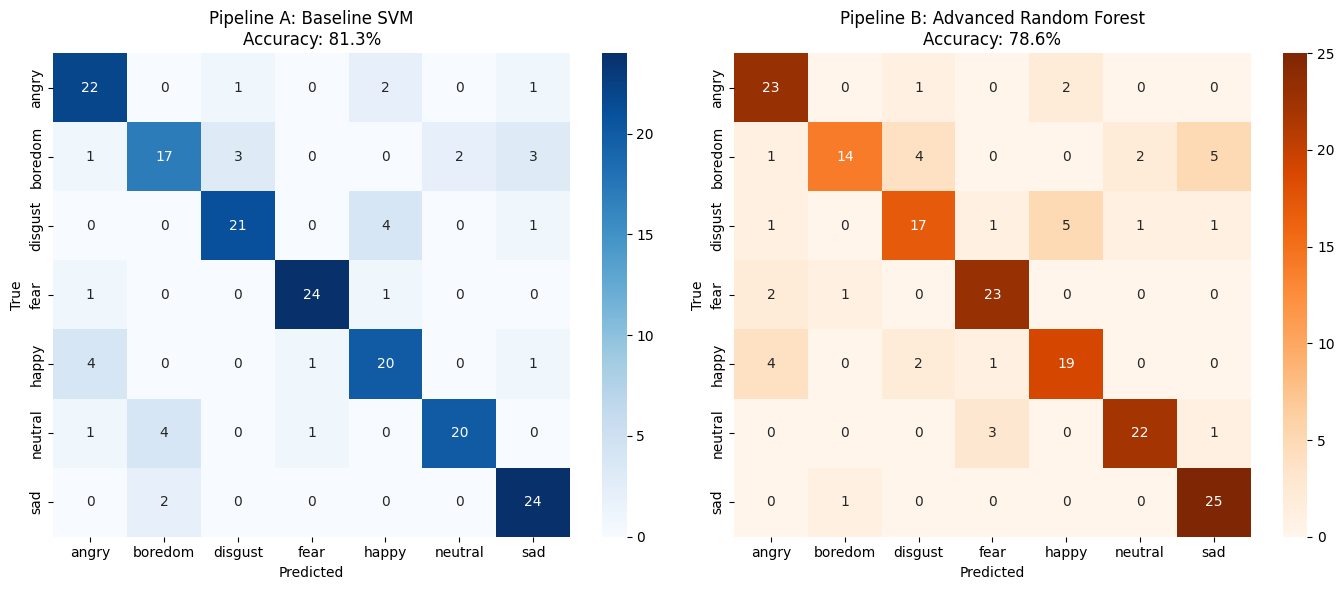

In [24]:
# ============================================================
# FINAL EVALUATION: PIPELINE A (SVM) vs PIPELINE B (Random Forest)
# ============================================================
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# --- Pipeline A Setup (Baseline) ---
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_PIPELINE_A, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
scaler_A = StandardScaler()
X_train_A_scaled = scaler_A.fit_transform(X_train_A)
X_test_A_scaled = scaler_A.transform(X_test_A)

# --- Pipeline B Setup (Advanced) ---
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_PIPELINE_B, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
scaler_B = StandardScaler()
X_train_B_scaled = scaler_B.fit_transform(X_train_B)
X_test_B_scaled = scaler_B.transform(X_test_B)

# 1. Train Baseline SVM (Pipeline A)
svm_model = SVC(kernel='rbf', C=10, gamma='scale')
svm_model.fit(X_train_A_scaled, y_train_A)
svm_preds = svm_model.predict(X_test_A_scaled)
svm_acc = accuracy_score(y_test_A, svm_preds)

# 2. Train Advanced Random Forest (Pipeline B)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, class_weight='balanced')
rf_model.fit(X_train_B_scaled, y_train_B) 
rf_preds = rf_model.predict(X_test_B_scaled)
rf_acc = accuracy_score(y_test_B, rf_preds)

print(f"Pipeline A (STE + Praat + SVM) Accuracy: {svm_acc:.4f}")
print(f"Pipeline B (VOP + pYIN + RF) Accuracy: {rf_acc:.4f}")

# --- Plotting the Results ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

try:
    emotions_decoded = le.inverse_transform(np.unique(y_encoded))
except NameError:
    emotions_decoded = np.unique(y_encoded)

sns.heatmap(confusion_matrix(y_test_A, svm_preds), annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotions_decoded, yticklabels=emotions_decoded, ax=axes[0])
axes[0].set_title(f'Pipeline A: Baseline SVM\nAccuracy: {svm_acc*100:.1f}%')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(confusion_matrix(y_test_B, rf_preds), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=emotions_decoded, yticklabels=emotions_decoded, ax=axes[1])
axes[1].set_title(f'Pipeline B: Advanced Random Forest\nAccuracy: {rf_acc*100:.1f}%')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

Extracting 3D Temporal Features for Bi-LSTM... (This takes a few minutes)


Processing Time-Steps: 100%|██████████| 910/910 [02:04<00:00,  7.33it/s]
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



✅ Final 3D Feature Shape: (910, 150, 27)
Training Bi-LSTM on Temporal Trajectories...
Epoch 1/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 208ms/step - accuracy: 0.3379 - loss: 1.7781 - val_accuracy: 0.4451 - val_loss: 1.7076
Epoch 2/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.5481 - loss: 1.2324 - val_accuracy: 0.5989 - val_loss: 1.5709
Epoch 3/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.6607 - loss: 0.9089 - val_accuracy: 0.6923 - val_loss: 1.3885
Epoch 4/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.7555 - loss: 0.6926 - val_accuracy: 0.7198 - val_loss: 1.2505
Epoch 5/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.8297 - loss: 0.5277 - val_accuracy: 0.7473 - val_loss: 1.0497
Epoch 6/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 0.8668 - loss: 0.3984 - val_accuracy: 0.8187 - val_loss: 0.8982
Epoch 7/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.9038 - loss: 0.3116 - val_accuracy: 0.8297 - val_loss: 0.7347
Epoch 8/40
23/23

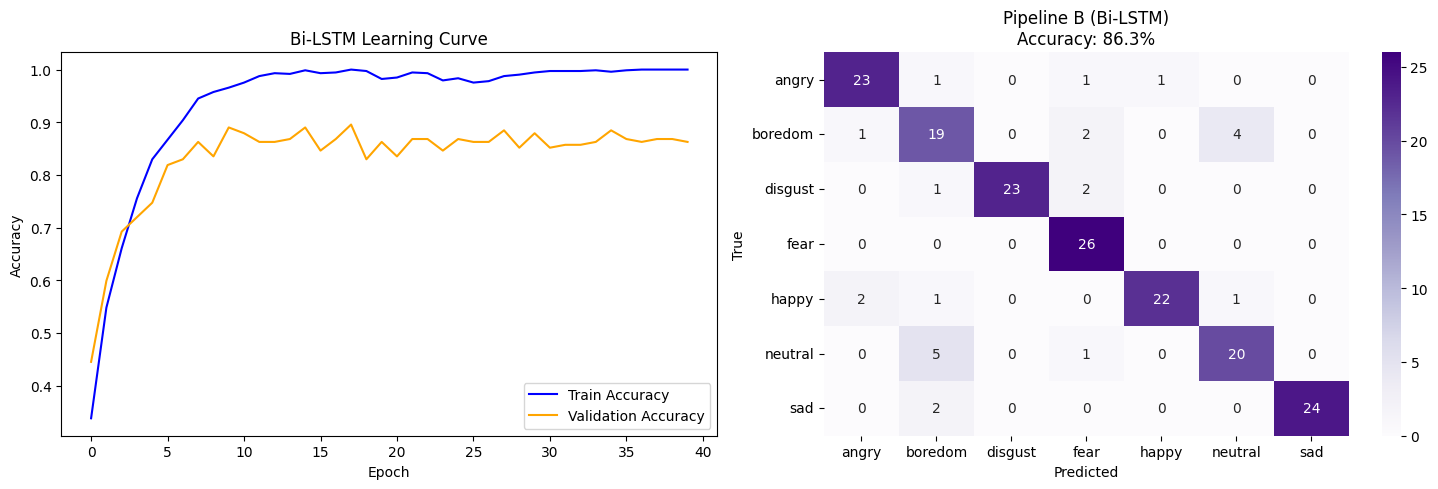

In [25]:
# ============================================================
# TRUE PIPELINE B: ADVANCED VOP + pYIN + Bi-LSTM (TEMPORAL)
# No averaging! We feed the sequential frames to TensorFlow.
# ============================================================

import numpy as np
import librosa
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def extract_temporal_pipeline_B(signal, sr=16000):
    """
    Extracts frame-by-frame temporal features from ONLY the VOP regions.
    Does NOT average them. Returns an array of shape (Time_Steps, Features).
    """
    regions = detect_vowel_regions_vop_vep(signal, sr)
    
    # Concatenate voiced segments
    if regions:
        voiced_signal = np.concatenate([signal[start:end] for start, end in regions])
    else:
        voiced_signal = signal 
        
    if len(voiced_signal) < 640:
        voiced_signal = signal 
        
    # Extract Sequential MFCCs (Time_Frames, 26)
    mfcc_seq = librosa.feature.mfcc(y=voiced_signal, sr=sr, n_mfcc=26).T
    
    # Extract Sequential pYIN Pitch
    f0_pyin, _, _ = librosa.pyin(voiced_signal, fmin=75, fmax=600, sr=sr)
    f0_pyin = np.nan_to_num(f0_pyin).reshape(-1, 1)
    
    min_len = min(mfcc_seq.shape[0], f0_pyin.shape[0])
    combined_seq = np.hstack((mfcc_seq[:min_len, :], f0_pyin[:min_len, :]))
    
    return combined_seq

print("Extracting 3D Temporal Features for Bi-LSTM... (This takes a few minutes)")

X_sequential_B = []
for sig in tqdm(X_audio, desc="Processing Time-Steps"):
    seq = extract_temporal_pipeline_B(sig, sr=16000)
    X_sequential_B.append(seq)

# Pad sequences so they all have the same time-step length for the Neural Network
MAX_TIME_STEPS = 150 
X_3D = pad_sequences(X_sequential_B, maxlen=MAX_TIME_STEPS, dtype='float32', padding='post', truncating='post')

print(f"\n✅ Final 3D Feature Shape: {X_3D.shape}")
np.save("X_PIPELINE_B_3D.npy", X_3D)

# ============================================================
# NEURAL NETWORK TRAINING
# ============================================================

# 1. Scale the 3D data
samples, time_steps, features = X_3D.shape
X_3D_reshaped = X_3D.reshape(-1, features)

scaler = StandardScaler()
X_3D_scaled = scaler.fit_transform(X_3D_reshaped).reshape(samples, time_steps, features)

# 2. One-Hot Encode Labels
num_classes = len(np.unique(y_encoded))
y_categorical = to_categorical(y_encoded, num_classes=num_classes)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_3D_scaled, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded)

# --- THE BI-LSTM ARCHITECTURE ---
model = Sequential()
# Masking layer tells the network to completely ignore the padded zeros!
model.add(Masking(mask_value=0.0, input_shape=(MAX_TIME_STEPS, features)))

# Bi-Directional sweeps forward and backward across the vowel
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(64, return_sequences=False)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Training Bi-LSTM on Temporal Trajectories...")
history = model.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# --- EVALUATION ---
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

bilstm_acc = accuracy_score(y_true, y_pred)
print(f"\n🚀 Pipeline B (Temporal Bi-LSTM) Accuracy: {bilstm_acc:.4f}")

# --- Plot the Results ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Bi-LSTM Learning Curve')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

try:
    emotions_decoded = le.inverse_transform(np.unique(y_encoded))
except NameError:
    emotions_decoded = np.unique(y_encoded)

sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Purples', 
            xticklabels=emotions_decoded, yticklabels=emotions_decoded, ax=axes[1])
axes[1].set_title(f'Pipeline B (Bi-LSTM)\nAccuracy: {bilstm_acc*100:.1f}%')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()